# 🏢 IBM HR Analytics — Employee Attrition Prediction
## End-to-End Machine Learning Project

---

**Dataset:** IBM HR Analytics Employee Attrition & Performance (Kaggle / IBM)  
**Task:** Binary Classification — Predict whether an employee will leave (Yes/No)  
**Business Problem:** Employee attrition costs companies 50–200% of annual salary per employee. Early prediction enables HR to intervene proactively.

### Project Pipeline
1. Data Loading & Inspection  
2. Missing Value Analysis & Data Cleaning  
3. Feature Engineering  
4. Exploratory Data Analysis (EDA)  
5. Feature Selection  
6. Model Training (Logistic Regression, Random Forest, Gradient Boosting)  
7. Hyperparameter Tuning (GridSearchCV)  
8. Final Evaluation & Summary

---


## 0. Imports & Configuration

In [1]:
import warnings
warnings.filterwarnings("ignore")

# Core
import numpy  as np
import pandas as pd

# Visualisation
import matplotlib.pyplot   as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches  as mpatches
import seaborn as sns

# Sklearn — Preprocessing
from sklearn.preprocessing     import LabelEncoder, StandardScaler
from sklearn.model_selection   import (train_test_split, StratifiedKFold,
                                        cross_val_score, GridSearchCV)
# Sklearn — Models
from sklearn.linear_model      import LogisticRegression
from sklearn.ensemble          import RandomForestClassifier, GradientBoostingClassifier

# Sklearn — Metrics
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve,
    precision_recall_curve, f1_score,
    average_precision_score, ConfusionMatrixDisplay
)
from sklearn.utils.class_weight import compute_class_weight

# Reproducibility
SEED = 42
np.random.seed(SEED)

# ── Plot style ────────────────────────────────────────────────────────────────
BG    = "#0A0F1E"
PANEL = "#111827"
BLUE  = "#3B82F6"
AMBER = "#F59E0B"
GREEN = "#10B981"
RED   = "#EF4444"
PURPLE= "#8B5CF6"
CREAM = "#F3F4F6"
GREY  = "#374151"

plt.rcParams.update({
    "figure.facecolor" : BG,
    "axes.facecolor"   : PANEL,
    "axes.edgecolor"   : "#1F2937",
    "axes.labelcolor"  : CREAM,
    "axes.titlecolor"  : CREAM,
    "xtick.color"      : CREAM,
    "ytick.color"      : CREAM,
    "text.color"       : CREAM,
    "grid.color"       : "#1F2937",
    "grid.linestyle"   : "--",
    "grid.alpha"       : 0.6,
    "font.family"      : "DejaVu Sans",
    "figure.dpi"       : 110,
    "axes.spines.top"  : False,
    "axes.spines.right": False,
})

print("✅ All libraries imported successfully!")
print(f"   NumPy {np.__version__}  |  Pandas {pd.__version__}")


✅ All libraries imported successfully!
   NumPy 2.0.2  |  Pandas 2.2.2


---
## 1. Data Loading & Inspection

We load the IBM HR Analytics dataset, which contains **1,470 employee records** across **35 features** including demographics, job details, satisfaction scores, and whether the employee left (Attrition).


In [2]:
# ── Load Dataset ──────────────────────────────────────────────────────────────
df = pd.read_csv("/content/WA_Fn-UseC_-HR-Employee-Attrition.csv")

print(f"Dataset Shape  : {df.shape[0]} rows × {df.shape[1]} columns")
print(f"\nColumn names:\n{list(df.columns)}")


Dataset Shape  : 1470 rows × 35 columns

Column names:
['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


In [3]:
# ── Preview the data ─────────────────────────────────────────────────────────
df.head()


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [4]:
# ── Data types ────────────────────────────────────────────────────────────────
print("Data Types:")
print(df.dtypes)


Data Types:
Age                          int64
Attrition                   object
BusinessTravel              object
DailyRate                    int64
Department                  object
DistanceFromHome             int64
Education                    int64
EducationField              object
EmployeeCount                int64
EmployeeNumber               int64
EnvironmentSatisfaction      int64
Gender                      object
HourlyRate                   int64
JobInvolvement               int64
JobLevel                     int64
JobRole                     object
JobSatisfaction              int64
MaritalStatus               object
MonthlyIncome                int64
MonthlyRate                  int64
NumCompaniesWorked           int64
Over18                      object
OverTime                    object
PercentSalaryHike            int64
PerformanceRating            int64
RelationshipSatisfaction     int64
StandardHours                int64
StockOptionLevel             int64
TotalWor

In [5]:
# ── Statistical summary ───────────────────────────────────────────────────────
df.describe().round(2)


,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.00,1470.00,1470.00,1470.00,1470.0,1470.00,1470.00,1470.00,1470.00,1470.00,...,1470.00,1470.0,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00
mean,36.92,802.49,9.19,2.91,1.0,1024.87,2.72,65.89,2.73,2.06,...,2.71,80.0,0.79,11.28,2.80,2.76,7.01,4.23,2.19,4.12
std,9.14,403.51,8.11,1.02,0.0,602.02,1.09,20.33,0.71,1.11,...,1.08,0.0,0.85,7.78,1.29,0.71,6.13,3.62,3.22,3.57
min,18.00,102.00,1.00,1.00,1.0,1.00,1.00,30.00,1.00,1.00,...,1.00,80.0,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00
25%,30.00,465.00,2.00,2.00,1.0,491.25,2.00,48.00,2.00,1.00,...,2.00,80.0,0.00,6.00,2.00,2.00,3.00,2.00,0.00,2.00
50%,36.00,802.00,7.00,3.00,1.0,1020.50,3.00,66.00,3.00,2.00,...,3.00,80.0,1.00,10.00,3.00,3.00,5.00,3.00,1.00,3.00
75%,43.00,1157.00,14.00,4.00,1.0,1555.75,4.00,83.75,3.00,3.00,...,4.00,80.0,1.00,15.00,3.00,3.00,9.00,7.00,3.00,7.00
max,60.00,1499.00,29.00,5.00,1.0,2068.00,4.00,100.00,4.00,5.00,...,4.00,80.0,3.00,40.00,6.00,4.00,40.00,18.00,15.00,17.00


In [6]:
# ── Target variable distribution ─────────────────────────────────────────────
print("Target: Attrition")
print(df["Attrition"].value_counts())
print(f"\nAttrition rate: {(df['Attrition']=='Yes').mean()*100:.1f}%")
print("⚠️  Class Imbalance detected — will handle with class_weight='balanced'")


Target: Attrition
Attrition
No     1233
Yes     237
Name: count, dtype: int64

Attrition rate: 16.1%
⚠️  Class Imbalance detected — will handle with class_weight='balanced'


In [7]:
# ── Categorical column unique values ─────────────────────────────────────────
cat_cols = df.select_dtypes("object").columns.tolist()
print("Categorical columns & unique values:")
for col in cat_cols:
    print(f"  {col:25s}: {list(df[col].unique())}")


Categorical columns & unique values:
  Attrition                : ['Yes', 'No']
  BusinessTravel           : ['Travel_Rarely', 'Travel_Frequently', 'Non-Travel']
  Department               : ['Sales', 'Research & Development', 'Human Resources']
  EducationField           : ['Life Sciences', 'Other', 'Medical', 'Marketing', 'Technical Degree', 'Human Resources']
  Gender                   : ['Female', 'Male']
  JobRole                  : ['Sales Executive', 'Research Scientist', 'Laboratory Technician', 'Manufacturing Director', 'Healthcare Representative', 'Manager', 'Sales Representative', 'Research Director', 'Human Resources']
  MaritalStatus            : ['Single', 'Married', 'Divorced']
  Over18                   : ['Y']
  OverTime                 : ['Yes', 'No']


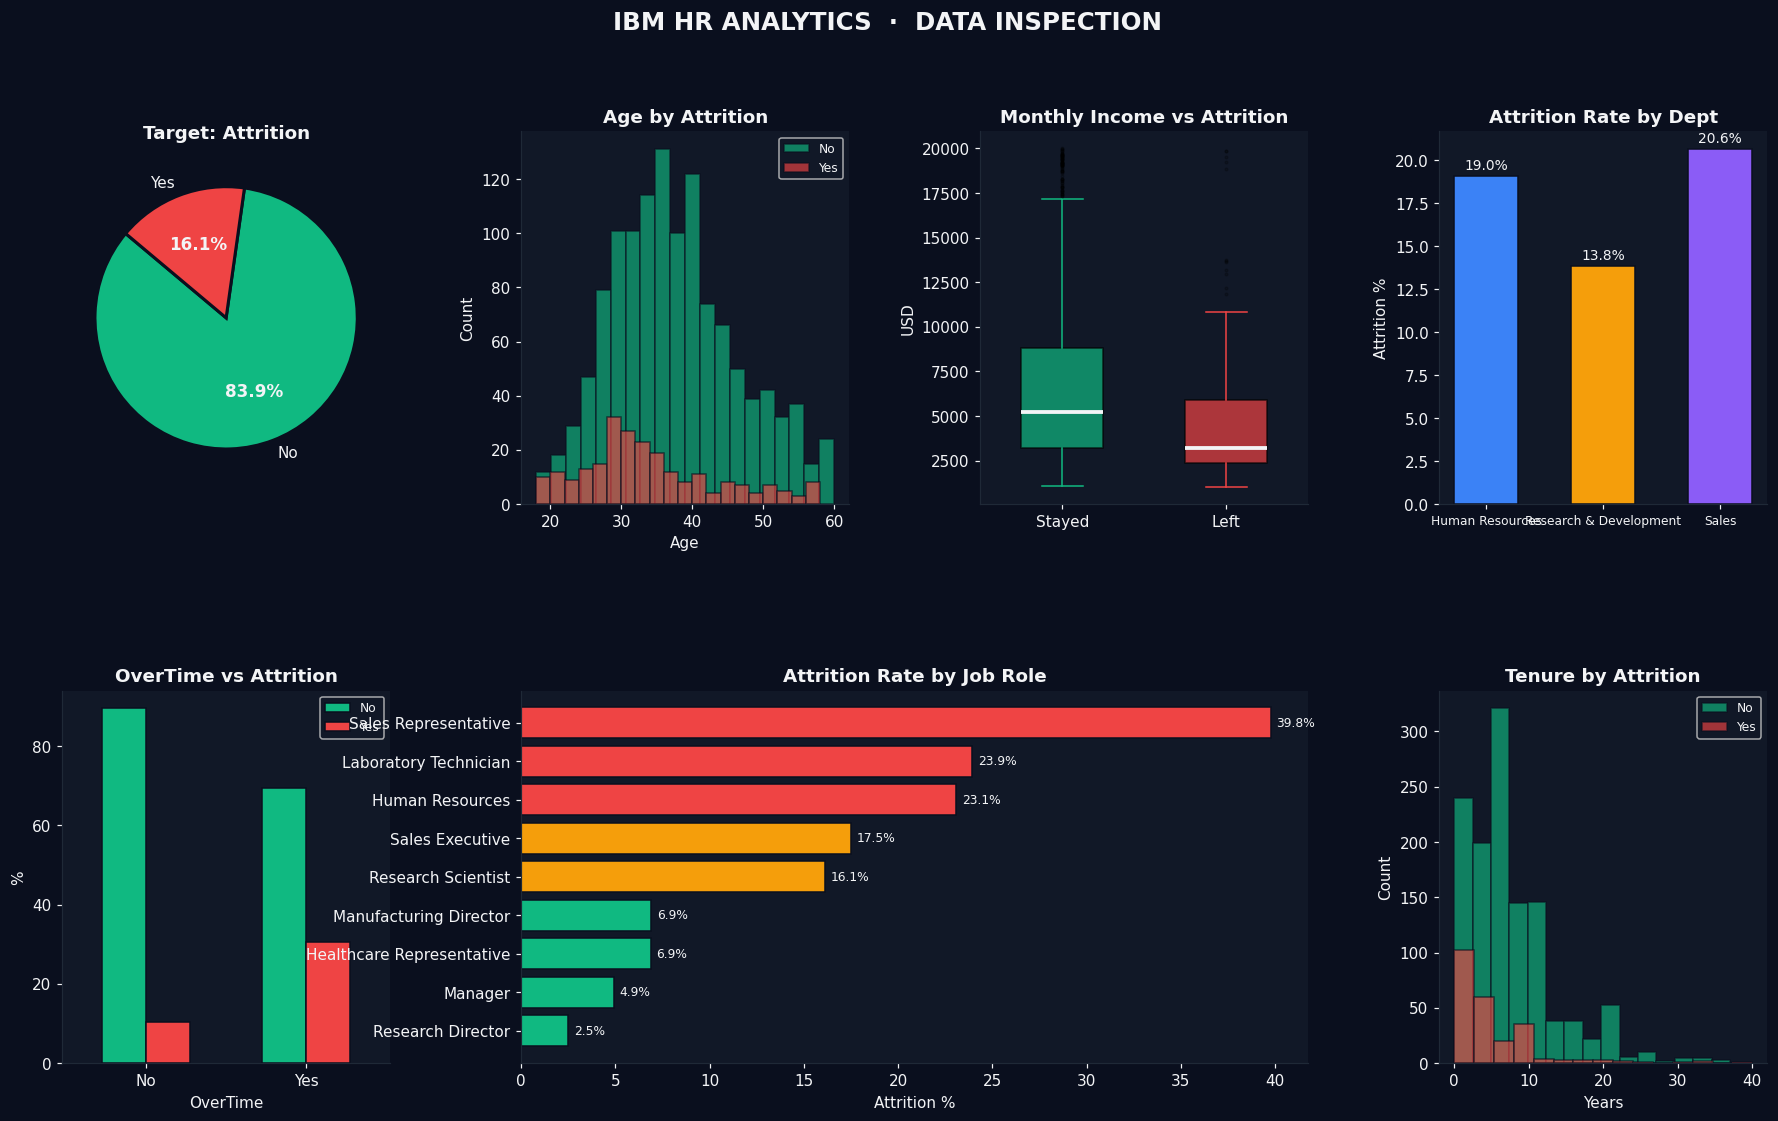

In [8]:
# ── Data Inspection Dashboard ─────────────────────────────────────────────────
fig = plt.figure(figsize=(20, 11), facecolor=BG)
fig.suptitle("IBM HR ANALYTICS  ·  DATA INSPECTION", fontsize=16,
             fontweight="bold", color=CREAM, y=0.98)
gs = gridspec.GridSpec(2, 4, figure=fig, hspace=0.50, wspace=0.40)

# Attrition pie
ax = fig.add_subplot(gs[0, 0])
counts = df["Attrition"].value_counts()
wedges, texts, ats = ax.pie(
    counts, labels=counts.index, autopct="%1.1f%%",
    colors=[GREEN, RED], startangle=140,
    wedgeprops=dict(edgecolor=BG, linewidth=2),
    textprops=dict(color=CREAM, fontsize=10))
[at.set(fontsize=11, fontweight="bold") for at in ats]
ax.set_title("Target: Attrition", fontweight="bold", pad=10)

# Age distribution
ax = fig.add_subplot(gs[0, 1])
for val, c in [("No", GREEN), ("Yes", RED)]:
    ax.hist(df[df["Attrition"]==val]["Age"], bins=20, color=c,
            alpha=0.65, label=val, edgecolor=BG)
ax.set_title("Age by Attrition", fontweight="bold")
ax.set_xlabel("Age"); ax.set_ylabel("Count"); ax.legend(fontsize=8)

# MonthlyIncome boxplot
ax = fig.add_subplot(gs[0, 2])
for i, (val, c) in enumerate([("No", GREEN), ("Yes", RED)]):
    ax.boxplot(df[df["Attrition"]==val]["MonthlyIncome"],
               positions=[i], patch_artist=True, widths=0.5,
               boxprops=dict(facecolor=c, alpha=0.7),
               medianprops=dict(color=CREAM, lw=2.5),
               whiskerprops=dict(color=c), capprops=dict(color=c),
               flierprops=dict(marker=".", color=c, alpha=0.3, markersize=3))
ax.set_xticks([0, 1]); ax.set_xticklabels(["Stayed", "Left"])
ax.set_title("Monthly Income vs Attrition", fontweight="bold"); ax.set_ylabel("USD")

# Department attrition rate
ax = fig.add_subplot(gs[0, 3])
dept_rate = df.groupby("Department")["Attrition"].apply(
    lambda x: (x=="Yes").mean()*100)
bars = ax.bar(dept_rate.index, dept_rate.values,
              color=[BLUE, AMBER, PURPLE], edgecolor=BG, width=0.55)
ax.set_title("Attrition Rate by Dept", fontweight="bold")
ax.set_ylabel("Attrition %"); ax.tick_params(axis="x", labelsize=8)
for b, v in zip(bars, dept_rate.values):
    ax.text(b.get_x()+b.get_width()/2, v+0.4, f"{v:.1f}%",
            ha="center", fontsize=9, color=CREAM)

# OverTime
ax = fig.add_subplot(gs[1, 0])
ot = df.groupby(["OverTime","Attrition"]).size().unstack()
(ot.div(ot.sum(axis=1), axis=0)*100).plot(
    kind="bar", ax=ax, color=[GREEN, RED], edgecolor=BG, width=0.55, rot=0)
ax.set_title("OverTime vs Attrition", fontweight="bold")
ax.set_xlabel("OverTime"); ax.set_ylabel("%"); ax.legend(fontsize=8)

# Job Role attrition
ax = fig.add_subplot(gs[1, 1:3])
role_rate = (df.groupby("JobRole")["Attrition"]
               .apply(lambda x: (x=="Yes").mean()*100)
               .sort_values(ascending=True))
ax.barh(role_rate.index, role_rate.values,
        color=[RED if v>20 else AMBER if v>12 else GREEN for v in role_rate.values],
        edgecolor=BG)
ax.set_title("Attrition Rate by Job Role", fontweight="bold")
ax.set_xlabel("Attrition %")
for i, v in enumerate(role_rate.values):
    ax.text(v+0.3, i, f"{v:.1f}%", va="center", fontsize=8)

# YearsAtCompany
ax = fig.add_subplot(gs[1, 3])
for val, c in [("No", GREEN), ("Yes", RED)]:
    ax.hist(df[df["Attrition"]==val]["YearsAtCompany"],
            bins=15, alpha=0.65, color=c, label=val, edgecolor=BG)
ax.set_title("Tenure by Attrition", fontweight="bold")
ax.set_xlabel("Years"); ax.set_ylabel("Count"); ax.legend(fontsize=8)

plt.tight_layout()
plt.show()


---
## 2. Missing Value Analysis & Data Cleaning

The IBM HR dataset is exceptionally clean — no missing values. However, we still need to:
- **Drop constant columns** (zero variance — useless for ML)
- **Drop identifier columns** (EmployeeNumber leaks no signal)
- Verify data quality


In [9]:
# ── Missing value check ───────────────────────────────────────────────────────
print("Missing values per column:")
missing = df.isnull().sum()
print(missing[missing > 0] if missing.any() else "✅ No missing values found!")
print(f"\nTotal missing cells: {df.isnull().sum().sum()}")


Missing values per column:
✅ No missing values found!

Total missing cells: 0


In [10]:
# ── Identify constant columns (zero variance — no predictive power) ────────────
constant_cols = [col for col in df.columns if df[col].nunique() == 1]
print(f"Constant columns (all rows have same value): {constant_cols}")
print("\nTheir unique values:")
for col in constant_cols:
    print(f"  {col}: {df[col].unique()}")


Constant columns (all rows have same value): ['EmployeeCount', 'Over18', 'StandardHours']

Their unique values:
  EmployeeCount: [1]
  Over18: ['Y']
  StandardHours: [80]


In [11]:
# ── Drop useless columns ──────────────────────────────────────────────────────
cols_to_drop = constant_cols + ["EmployeeNumber"]
df_clean = df.drop(columns=cols_to_drop)

print(f"Columns dropped: {cols_to_drop}")
print(f"Shape before: {df.shape}  →  Shape after: {df_clean.shape}")


Columns dropped: ['EmployeeCount', 'Over18', 'StandardHours', 'EmployeeNumber']
Shape before: (1470, 35)  →  Shape after: (1470, 31)


In [12]:
# ── Duplicate rows check ─────────────────────────────────────────────────────
dupes = df_clean.duplicated().sum()
print(f"Duplicate rows: {dupes}")
print("✅ Dataset is clean and ready for feature engineering!")


Duplicate rows: 0
✅ Dataset is clean and ready for feature engineering!


---
## 3. Feature Engineering

We transform raw features and create new meaningful features that capture employee risk signals not directly present in the raw data.

**Encoding strategy:**
- `Attrition` → binary target (1 = left, 0 = stayed)
- `BusinessTravel` → ordinal (0=None, 1=Rarely, 2=Frequently)
- `OverTime`, `Gender` → binary
- `Department`, `EducationField`, `JobRole`, `MaritalStatus` → one-hot

**Engineered features:**
| Feature | Rationale |
|---|---|
| `SatisfactionScore` | Composite of Job + Environment + Relationship satisfaction |
| `TenureRatio` | Years at company / total experience — loyalty indicator |
| `PromotionLag` | Time since promotion minus time in current role — frustration proxy |
| `IsJunior` | JobLevel ≤ 2 — junior employees leave more |
| `LowSatisfaction` | Flag: composite score < 2.5 |
| `IncomePerYear` | Monthly income × 12 |


In [13]:
# ── Encode target variable ────────────────────────────────────────────────────
df_clean = df_clean.copy()
df_clean["Attrition_bin"] = (df_clean["Attrition"] == "Yes").astype(int)
print("Target encoded: Yes→1, No→0")
print(df_clean["Attrition_bin"].value_counts())


Target encoded: Yes→1, No→0
Attrition_bin
0    1233
1     237
Name: count, dtype: int64


In [14]:
# ── Ordinal encoding ─────────────────────────────────────────────────────────
travel_map = {"Non-Travel": 0, "Travel_Rarely": 1, "Travel_Frequently": 2}
df_clean["BusinessTravel_ord"] = df_clean["BusinessTravel"].map(travel_map)
print("BusinessTravel ordinal mapping:", travel_map)


BusinessTravel ordinal mapping: {'Non-Travel': 0, 'Travel_Rarely': 1, 'Travel_Frequently': 2}


In [15]:
# ── Binary encoding ───────────────────────────────────────────────────────────
df_clean["OverTime_bin"] = (df_clean["OverTime"] == "Yes").astype(int)
df_clean["Gender_bin"]   = (df_clean["Gender"]   == "Male").astype(int)
print("OverTime  : Yes→1, No→0")
print("Gender    : Male→1, Female→0")


OverTime  : Yes→1, No→0
Gender    : Male→1, Female→0


In [16]:
# ── One-hot encoding for nominal categoricals ─────────────────────────────────
ohe_cols = ["Department", "EducationField", "JobRole", "MaritalStatus"]
df_enc = pd.get_dummies(df_clean, columns=ohe_cols, drop_first=False)

# Drop original string columns no longer needed
drop_str = ["Attrition", "BusinessTravel", "OverTime", "Gender"]
drop_str += [c for c in df_enc.columns if df_enc[c].dtype == object]
df_enc.drop(columns=[c for c in drop_str if c in df_enc.columns], inplace=True)

print(f"Shape after encoding: {df_enc.shape}")


Shape after encoding: (1470, 48)


In [17]:
# ── Engineered features ───────────────────────────────────────────────────────
df_enc["SatisfactionScore"] = (
    df_enc["JobSatisfaction"] +
    df_enc["EnvironmentSatisfaction"] +
    df_enc["RelationshipSatisfaction"]
) / 3

df_enc["TenureRatio"] = (
    df_enc["YearsAtCompany"] / (df_enc["TotalWorkingYears"] + 1)
)

df_enc["PromotionLag"] = (
    df_enc["YearsSinceLastPromotion"] - df_enc["YearsInCurrentRole"]
)

df_enc["IsJunior"]      = (df_enc["JobLevel"] <= 2).astype(int)
df_enc["LowSatisfaction"]= (df_enc["SatisfactionScore"] < 2.5).astype(int)
df_enc["IncomePerYear"]  = df_enc["MonthlyIncome"] * 12

print("✅ Engineered features created:")
engineered = ["SatisfactionScore","TenureRatio","PromotionLag","IsJunior","LowSatisfaction","IncomePerYear"]
print(df_enc[engineered].describe().round(3))


✅ Engineered features created:
       SatisfactionScore  TenureRatio  PromotionLag  IsJunior  \
count           1470.000     1470.000      1470.000  1470.000   
mean               2.721        0.582        -2.041     0.733   
std                0.628        0.284         3.273     0.443   
min                1.000        0.000       -16.000     0.000   
25%                2.333        0.368        -4.000     0.000   
50%                2.667        0.636        -1.000     1.000   
75%                3.333        0.833         0.000     1.000   
max                4.000        0.976        10.000     1.000   

       LowSatisfaction  IncomePerYear  
count         1470.000       1470.000  
mean             0.363      78035.176  
std              0.481      56495.481  
min              0.000      12108.000  
25%              0.000      34932.000  
50%              0.000      59028.000  
75%              1.000     100548.000  
max              1.000     239988.000  


In [18]:
# ── Final dataset shape ───────────────────────────────────────────────────────
print(f"Final feature matrix: {df_enc.shape[0]} rows × {df_enc.shape[1]-1} features + 1 target")
print(f"\nAll columns ({df_enc.shape[1]}):")
print(list(df_enc.columns))


Final feature matrix: 1470 rows × 53 features + 1 target

All columns (54):
['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager', 'Attrition_bin', 'BusinessTravel_ord', 'OverTime_bin', 'Gender_bin', 'Department_Human Resources', 'Department_Research & Development', 'Department_Sales', 'EducationField_Human Resources', 'EducationField_Life Sciences', 'EducationField_Marketing', 'EducationField_Medical', 'EducationField_Other', 'EducationField_Technical Degree', 'JobRole_Healthcare Representative', 'JobRole_Human Resources', 'JobRole_Laboratory Technician', 'JobRole_Manager', 'JobRole_Manufacturing Direct

---
## 4. Exploratory Data Analysis (EDA)

We explore how features relate to attrition, identifying key risk patterns that will guide feature selection and model interpretation.


### 4.1 Feature Correlation with Attrition

In [19]:
# ── Correlation with target ───────────────────────────────────────────────────
num_feat = [c for c in df_enc.select_dtypes(include=np.number).columns
            if c != "Attrition_bin"]
corr_target = (df_enc[num_feat + ["Attrition_bin"]]
               .corr()["Attrition_bin"]
               .drop("Attrition_bin")
               .sort_values())

# Top risk (positive) and protective (negative) factors
print("Top RISK factors (positive correlation with attrition):")
print(corr_target.tail(8).round(3).to_string())
print("\nTop PROTECTIVE factors (negative correlation with attrition):")
print(corr_target.head(8).round(3).to_string())


Top RISK factors (positive correlation with attrition):
Gender_bin            0.029
NumCompaniesWorked    0.043
DistanceFromHome      0.078
IsJunior              0.089
LowSatisfaction       0.123
BusinessTravel_ord    0.127
PromotionLag          0.145
OverTime_bin          0.246

Top PROTECTIVE factors (negative correlation with attrition):
TotalWorkingYears      -0.171
JobLevel               -0.169
YearsInCurrentRole     -0.161
IncomePerYear          -0.160
MonthlyIncome          -0.160
Age                    -0.159
YearsWithCurrManager   -0.156
SatisfactionScore      -0.147


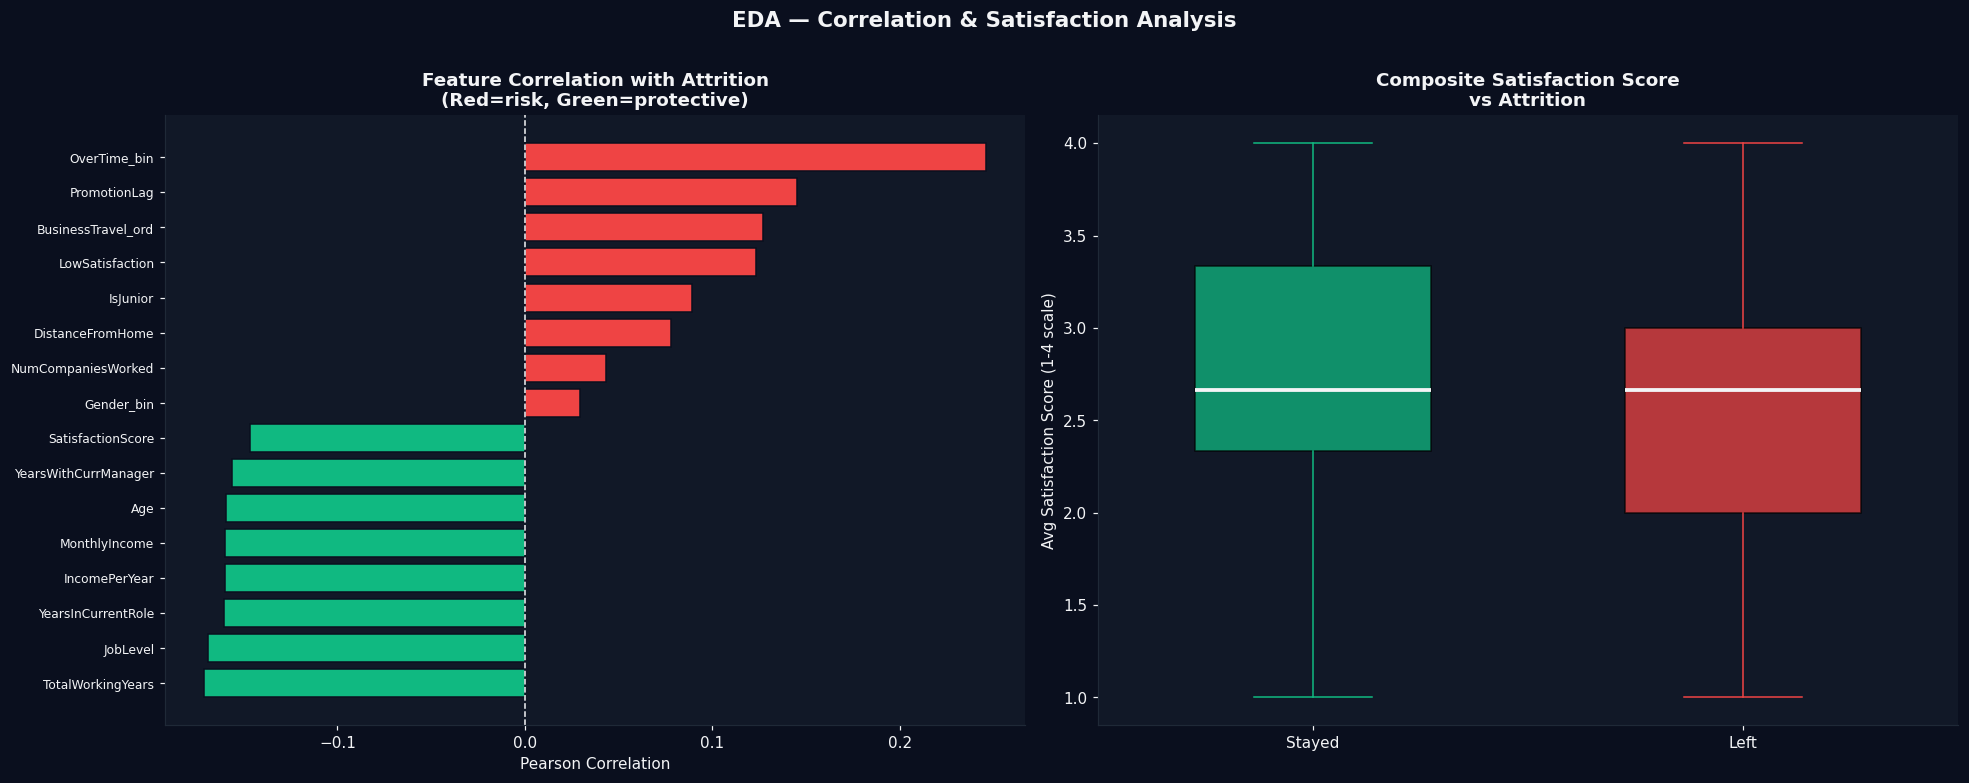

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7), facecolor=BG)
fig.suptitle("EDA — Correlation & Satisfaction Analysis",
             fontsize=14, fontweight="bold", color=CREAM, y=1.01)

# Correlation bar chart
comb = pd.concat([corr_target.head(8), corr_target.tail(8)])
axes[0].barh(range(len(comb)), comb.values,
             color=[RED if v > 0 else GREEN for v in comb.values],
             edgecolor=BG)
axes[0].set_yticks(range(len(comb)))
axes[0].set_yticklabels(comb.index, fontsize=8)
axes[0].axvline(0, color=CREAM, lw=1, ls="--")
axes[0].set_title("Feature Correlation with Attrition\n(Red=risk, Green=protective)",
                   fontweight="bold")
axes[0].set_xlabel("Pearson Correlation")

# Satisfaction score boxplot
for i, (val, c) in enumerate([("No", GREEN), ("Yes", RED)]):
    vals = df_enc[df_enc["Attrition_bin"] == (1 if val=="Yes" else 0)]["SatisfactionScore"]
    axes[1].boxplot(vals, positions=[i], patch_artist=True, widths=0.55,
                    boxprops=dict(facecolor=c, alpha=0.75),
                    medianprops=dict(color=CREAM, lw=2.5),
                    whiskerprops=dict(color=c), capprops=dict(color=c),
                    flierprops=dict(marker=".", color=c, alpha=0.3, markersize=3))
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(["Stayed", "Left"], fontsize=10)
axes[1].set_title("Composite Satisfaction Score\nvs Attrition", fontweight="bold")
axes[1].set_ylabel("Avg Satisfaction Score (1-4 scale)")

plt.tight_layout()
plt.show()


### 4.2 Correlation Heatmap

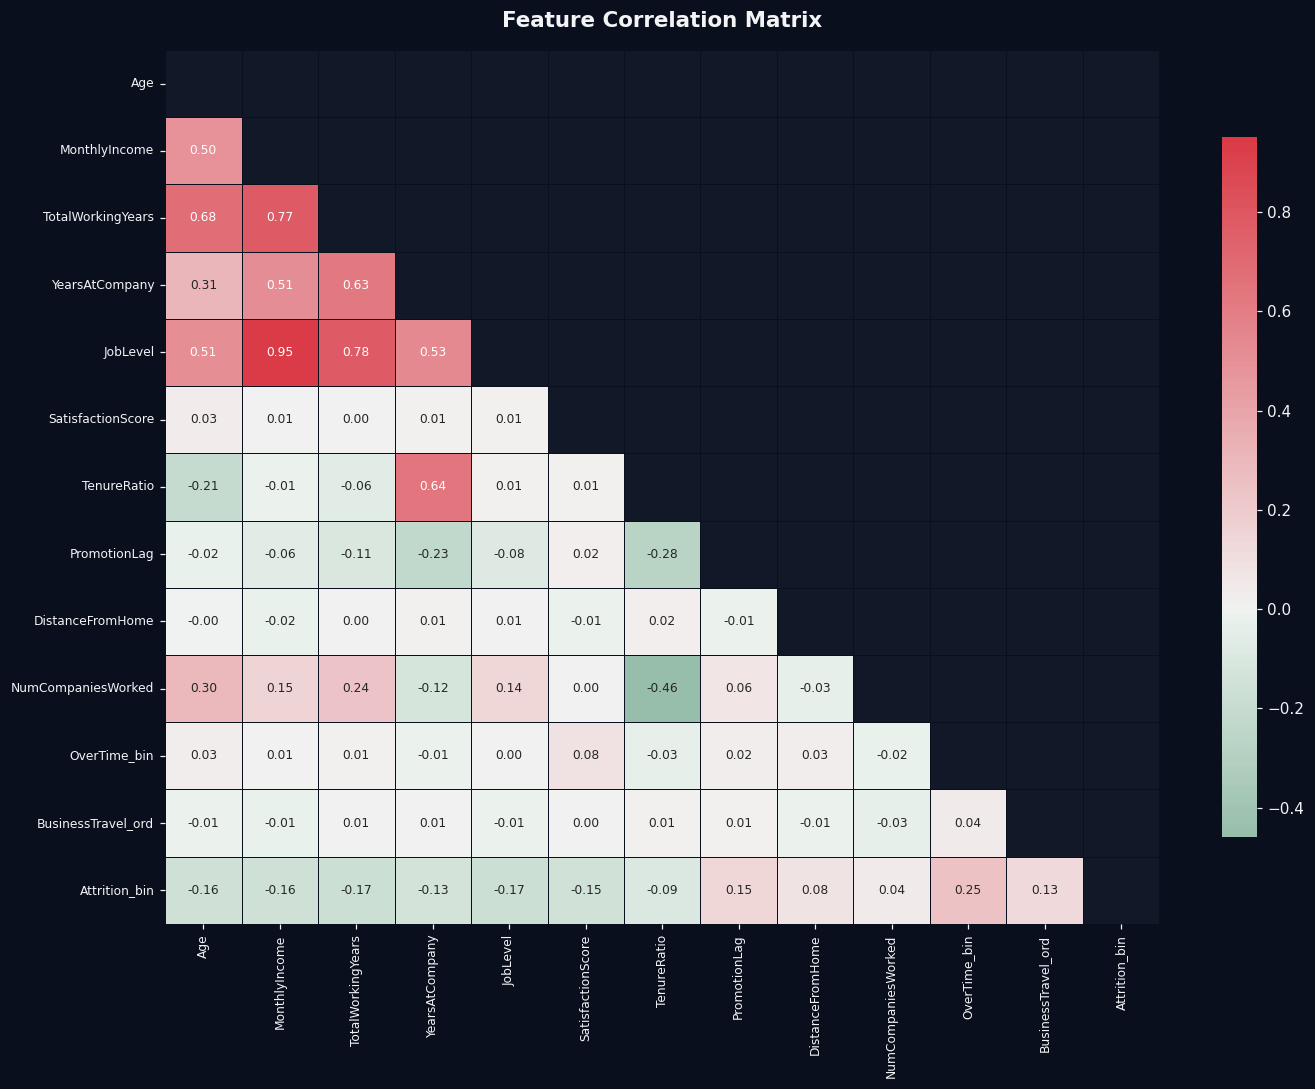

In [21]:
core_cols = [
    "Age", "MonthlyIncome", "TotalWorkingYears", "YearsAtCompany",
    "JobLevel", "SatisfactionScore", "TenureRatio", "PromotionLag",
    "DistanceFromHome", "NumCompaniesWorked", "OverTime_bin",
    "BusinessTravel_ord", "Attrition_bin"
]

fig, ax = plt.subplots(figsize=(13, 10), facecolor=BG)
corr_mat = df_enc[core_cols].corr()
mask = np.triu(np.ones_like(corr_mat, dtype=bool))

sns.heatmap(corr_mat, mask=mask,
            cmap=sns.diverging_palette(145, 10, as_cmap=True),
            center=0, ax=ax, annot=True, fmt=".2f",
            annot_kws={"size": 8},
            linewidths=0.4, linecolor=BG,
            cbar_kws={"shrink": 0.8})
ax.set_title("Feature Correlation Matrix", fontsize=14, fontweight="bold", pad=15)
ax.tick_params(labelsize=8)
plt.tight_layout()
plt.show()


### 4.3 Attrition Deep Dive

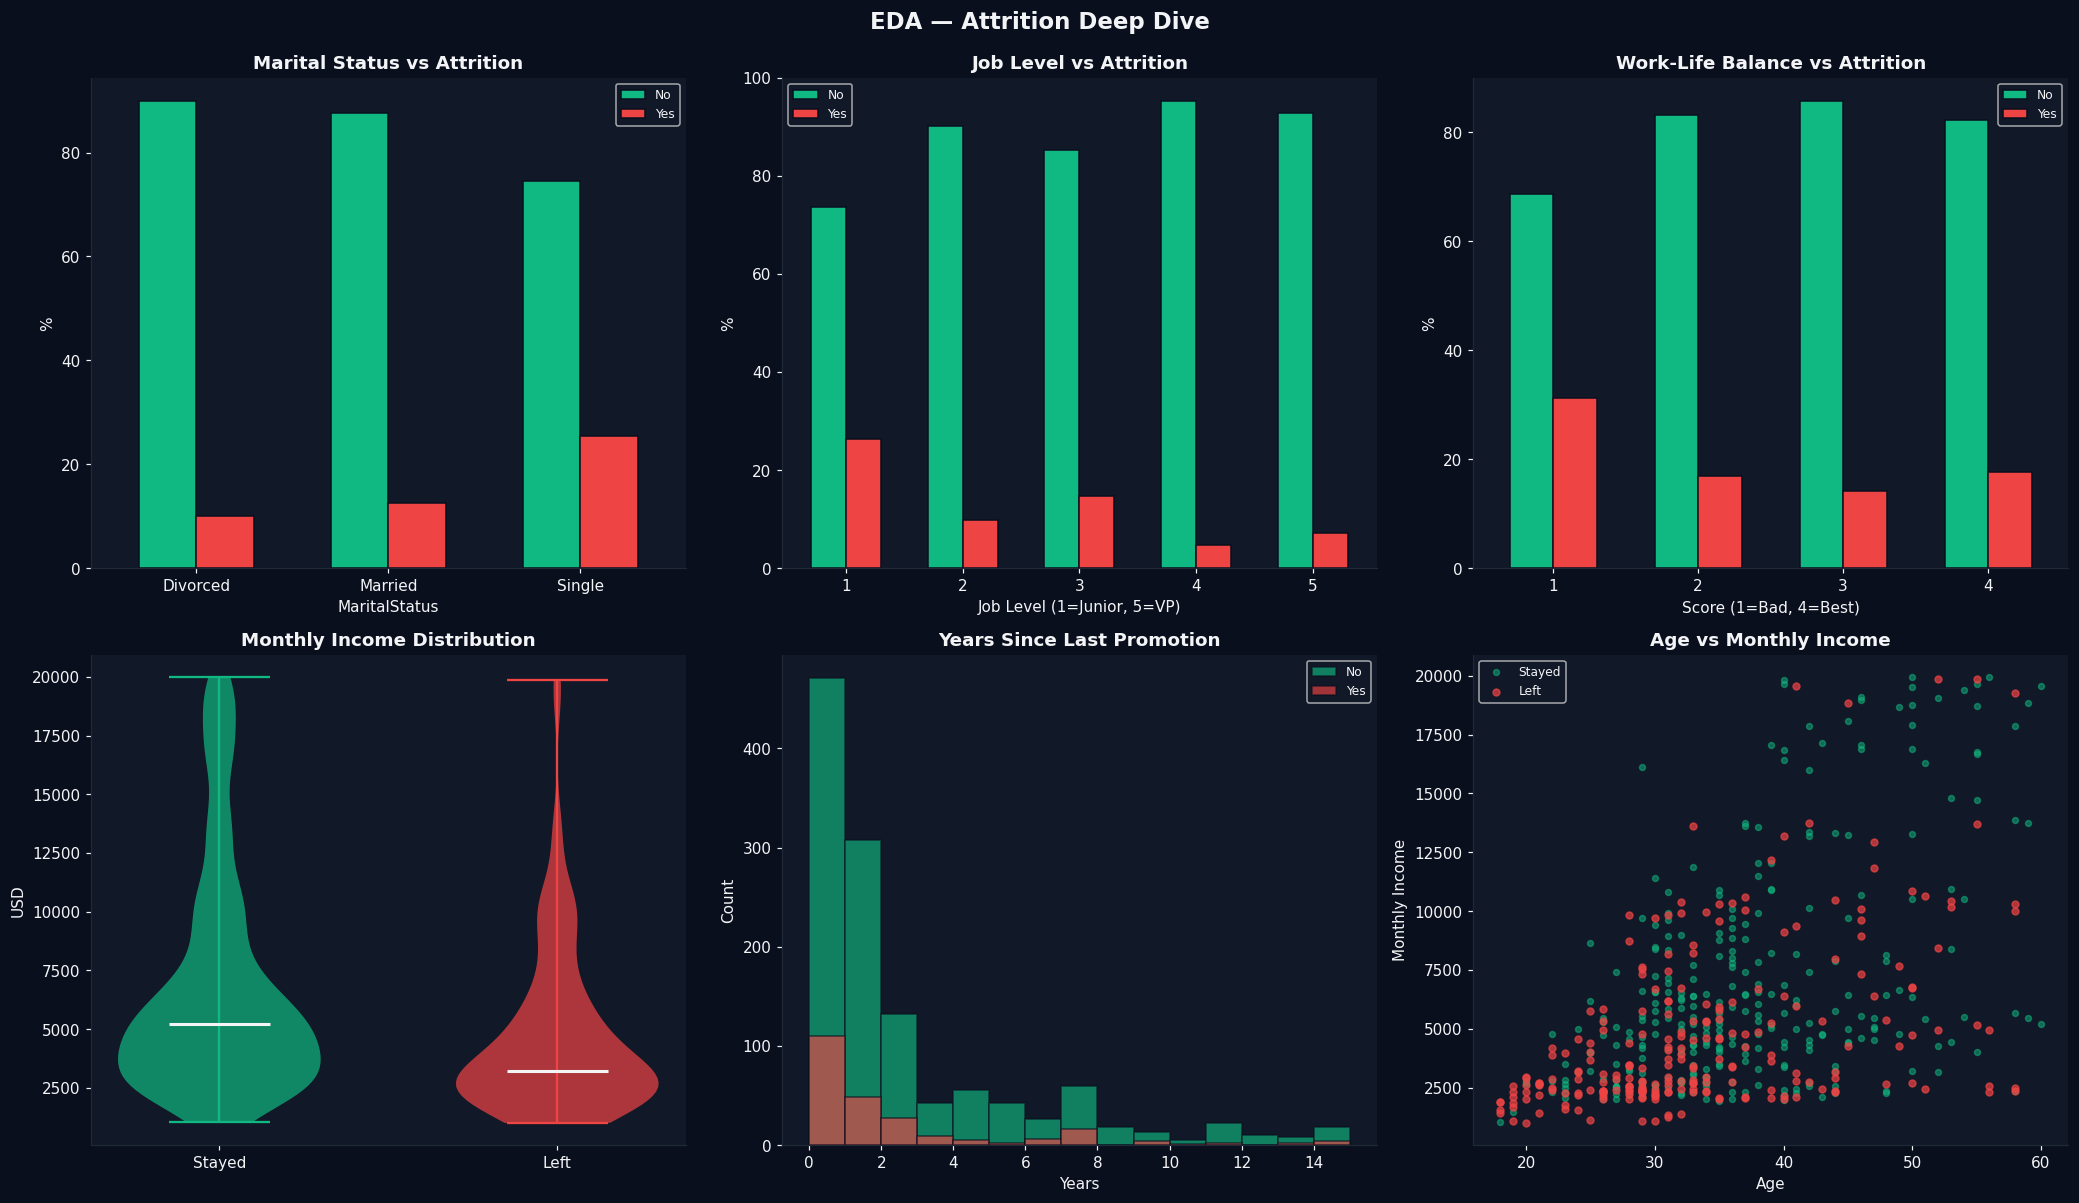

In [22]:
fig, axes = plt.subplots(2, 3, figsize=(19, 11), facecolor=BG)
fig.suptitle("EDA — Attrition Deep Dive", fontsize=15,
             fontweight="bold", color=CREAM, y=0.99)
axes = axes.flatten()

# MaritalStatus
ms = df.groupby(["MaritalStatus","Attrition"]).size().unstack()
(ms.div(ms.sum(axis=1), axis=0)*100).plot(
    kind="bar", ax=axes[0], color=[GREEN, RED], edgecolor=BG, width=0.6, rot=0)
axes[0].set_title("Marital Status vs Attrition", fontweight="bold")
axes[0].set_ylabel("%"); axes[0].legend(fontsize=8)

# JobLevel
jl = df.groupby(["JobLevel","Attrition"]).size().unstack()
(jl.div(jl.sum(axis=1), axis=0)*100).plot(
    kind="bar", ax=axes[1], color=[GREEN, RED], edgecolor=BG, width=0.6, rot=0)
axes[1].set_title("Job Level vs Attrition", fontweight="bold")
axes[1].set_xlabel("Job Level (1=Junior, 5=VP)")
axes[1].set_ylabel("%"); axes[1].legend(fontsize=8)

# WorkLifeBalance
wl = df.groupby(["WorkLifeBalance","Attrition"]).size().unstack()
(wl.div(wl.sum(axis=1), axis=0)*100).plot(
    kind="bar", ax=axes[2], color=[GREEN, RED], edgecolor=BG, width=0.6, rot=0)
axes[2].set_title("Work-Life Balance vs Attrition", fontweight="bold")
axes[2].set_xlabel("Score (1=Bad, 4=Best)")
axes[2].set_ylabel("%"); axes[2].legend(fontsize=8)

# MonthlyIncome violin
for i, (val, c) in enumerate([("No", GREEN), ("Yes", RED)]):
    vals = df[df["Attrition"]==val]["MonthlyIncome"]
    vp = axes[3].violinplot(vals, positions=[i], showmedians=True, widths=0.6)
    for pc in vp["bodies"]: pc.set_facecolor(c); pc.set_alpha(0.7)
    vp["cmedians"].set_color(CREAM); vp["cmedians"].set_linewidth(2)
    for k in ["cmins","cmaxes","cbars"]: vp[k].set_color(c)
axes[3].set_xticks([0,1]); axes[3].set_xticklabels(["Stayed","Left"])
axes[3].set_title("Monthly Income Distribution", fontweight="bold"); axes[3].set_ylabel("USD")

# YearsSinceLastPromotion
for val, c in [("No", GREEN), ("Yes", RED)]:
    axes[4].hist(df[df["Attrition"]==val]["YearsSinceLastPromotion"],
                 bins=15, alpha=0.65, color=c, label=val, edgecolor=BG)
axes[4].set_title("Years Since Last Promotion", fontweight="bold")
axes[4].set_xlabel("Years"); axes[4].set_ylabel("Count"); axes[4].legend(fontsize=8)

# Age vs MonthlyIncome scatter
stayed = df[df["Attrition"]=="No"].sample(300, random_state=42)
left   = df[df["Attrition"]=="Yes"]
axes[5].scatter(stayed["Age"], stayed["MonthlyIncome"],
                c=GREEN, s=15, alpha=0.5, label="Stayed")
axes[5].scatter(left["Age"], left["MonthlyIncome"],
                c=RED, s=20, alpha=0.7, label="Left")
axes[5].set_title("Age vs Monthly Income", fontweight="bold")
axes[5].set_xlabel("Age"); axes[5].set_ylabel("Monthly Income")
axes[5].legend(fontsize=8)

plt.tight_layout()
plt.show()


### 4.4 Key Risk Factors

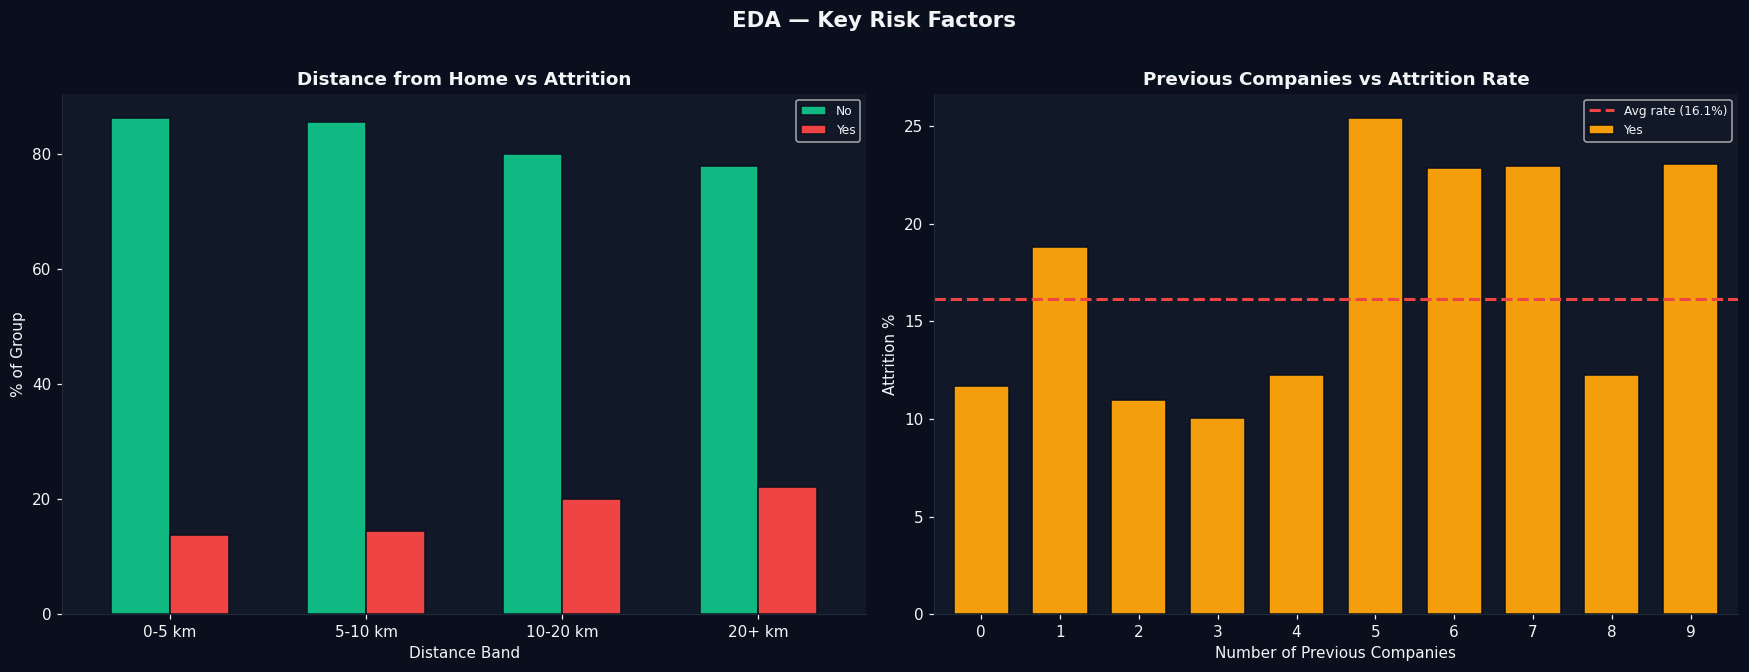

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6), facecolor=BG)
fig.suptitle("EDA — Key Risk Factors", fontsize=14,
             fontweight="bold", color=CREAM, y=1.01)

# Distance from home
df_temp = df.copy()
df_temp["DistBin"] = pd.cut(df_temp["DistanceFromHome"],
                             bins=[0, 5, 10, 20, 30],
                             labels=["0-5 km","5-10 km","10-20 km","20+ km"])
dist = df_temp.groupby(["DistBin","Attrition"]).size().unstack()
(dist.div(dist.sum(axis=1), axis=0)*100).plot(
    kind="bar", ax=axes[0], color=[GREEN, RED], edgecolor=BG, width=0.6, rot=0)
axes[0].set_title("Distance from Home vs Attrition", fontweight="bold")
axes[0].set_xlabel("Distance Band"); axes[0].set_ylabel("% of Group")
axes[0].legend(fontsize=8)

# Number of previous companies
nc = df.groupby(["NumCompaniesWorked","Attrition"]).size().unstack().fillna(0)
attrition_pct = (nc.div(nc.sum(axis=1), axis=0)*100)["Yes"]
attrition_pct.plot(kind="bar", ax=axes[1], color=AMBER, edgecolor=BG, width=0.7, rot=0)
axes[1].set_title("Previous Companies vs Attrition Rate", fontweight="bold")
axes[1].set_xlabel("Number of Previous Companies")
axes[1].set_ylabel("Attrition %")
avg_rate = df["Attrition"].eq("Yes").mean() * 100
axes[1].axhline(avg_rate, color=RED, ls="--", lw=2, label=f"Avg rate ({avg_rate:.1f}%)")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()


---
## 5. Feature Selection

We use a **Random Forest with balanced class weights** to compute feature importances (Gini impurity reduction), then select the top-20 most predictive features for model training.

This reduces noise, prevents overfitting, and speeds up training.


In [24]:
# ── Prepare X, y ─────────────────────────────────────────────────────────────
TARGET    = "Attrition_bin"
all_feats = [c for c in df_enc.columns if c != TARGET]
X = df_enc[all_feats].astype(float)
y = df_enc[TARGET]

print(f"Feature matrix shape : {X.shape}")
print(f"Target distribution  : {dict(y.value_counts())}")


Feature matrix shape : (1470, 53)
Target distribution  : {0: np.int64(1233), 1: np.int64(237)}


In [25]:
# ── Random Forest for importance scoring ──────────────────────────────────────
rf_selector = RandomForestClassifier(
    n_estimators=100,
    random_state=SEED,
    n_jobs=1,
    class_weight="balanced",
    max_depth=10
)
rf_selector.fit(X, y)

# Feature importances
feature_importances = pd.Series(
    rf_selector.feature_importances_,
    index=all_feats
).sort_values(ascending=False)

TOP_N     = 20
top_feats = feature_importances.head(TOP_N).index.tolist()

print(f"Top {TOP_N} features selected:")
print(feature_importances.head(TOP_N).round(4).to_string())


Top 20 features selected:
OverTime_bin            0.0639
IncomePerYear           0.0557
MonthlyIncome           0.0535
Age                     0.0431
DailyRate               0.0420
StockOptionLevel        0.0403
TenureRatio             0.0396
TotalWorkingYears       0.0394
SatisfactionScore       0.0380
MonthlyRate             0.0357
YearsAtCompany          0.0338
PromotionLag            0.0337
DistanceFromHome        0.0333
HourlyRate              0.0332
YearsWithCurrManager    0.0287
JobLevel                0.0260
PercentSalaryHike       0.0259
NumCompaniesWorked      0.0248
YearsInCurrentRole      0.0224
JobSatisfaction         0.0220


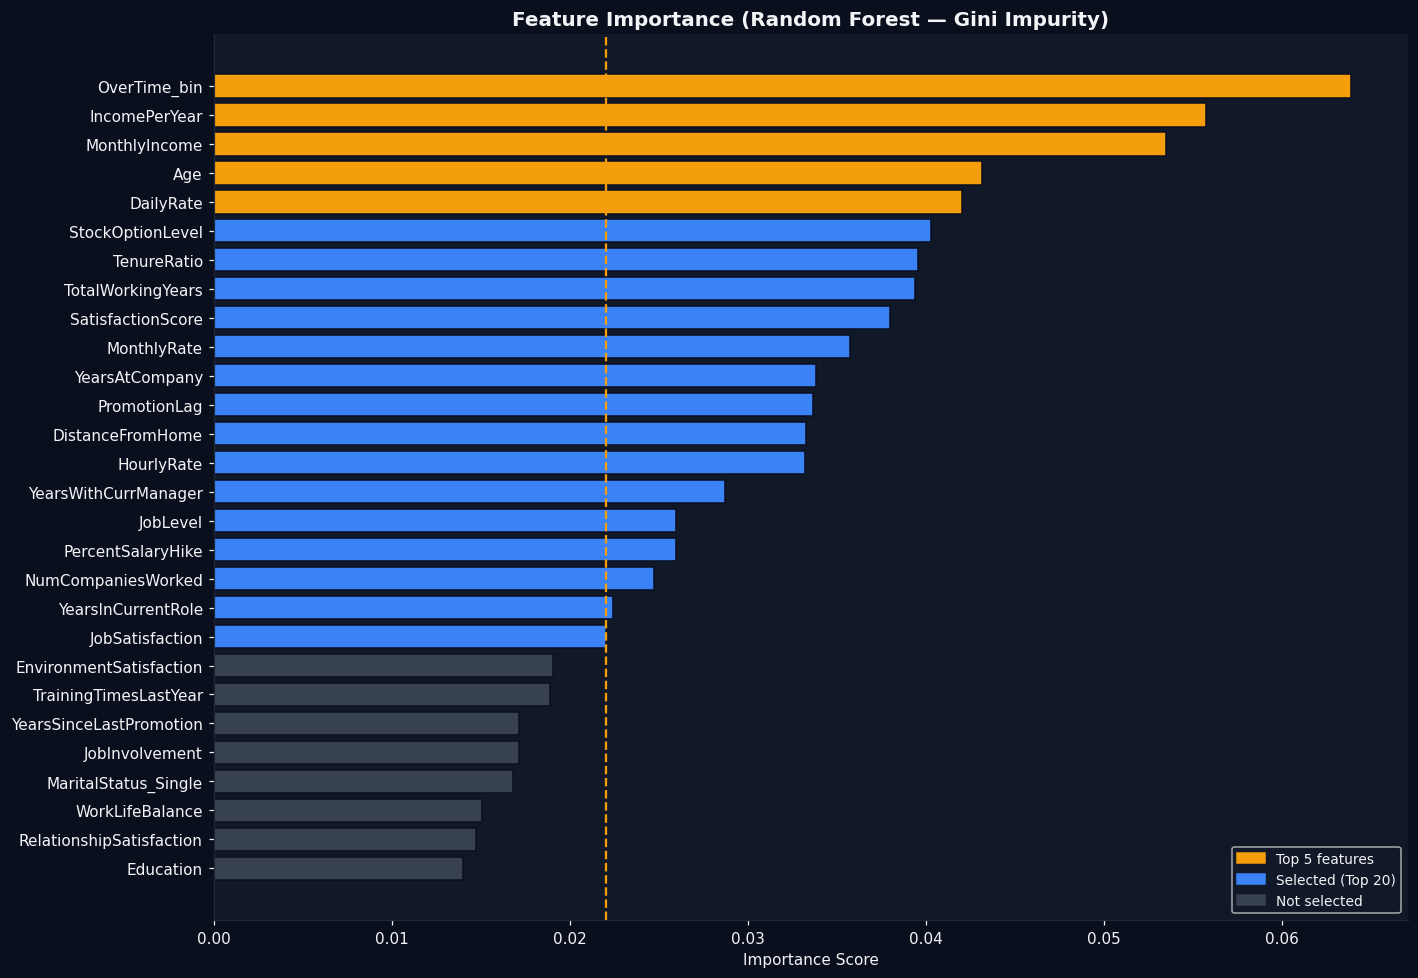


Selected features: ['OverTime_bin', 'IncomePerYear', 'MonthlyIncome', 'Age', 'DailyRate', 'StockOptionLevel', 'TenureRatio', 'TotalWorkingYears', 'SatisfactionScore', 'MonthlyRate', 'YearsAtCompany', 'PromotionLag', 'DistanceFromHome', 'HourlyRate', 'YearsWithCurrManager', 'JobLevel', 'PercentSalaryHike', 'NumCompaniesWorked', 'YearsInCurrentRole', 'JobSatisfaction']


In [26]:
# ── Feature importance visualisation ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 9), facecolor=BG)

bar_colors = [
    AMBER if f in top_feats[:5] else
    BLUE  if f in top_feats      else
    GREY
    for f in feature_importances.head(28).index
]

ax.barh(feature_importances.head(28).index[::-1],
        feature_importances.head(28).values[::-1],
        color=bar_colors[::-1], edgecolor=BG)

ax.axvline(feature_importances.iloc[TOP_N-1], color=AMBER,
           lw=1.5, ls="--", label=f"Top-{TOP_N} cutoff")
ax.set_title("Feature Importance (Random Forest — Gini Impurity)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Importance Score")

p1 = mpatches.Patch(color=AMBER, label="Top 5 features")
p2 = mpatches.Patch(color=BLUE,  label=f"Selected (Top {TOP_N})")
p3 = mpatches.Patch(color=GREY,  label="Not selected")
ax.legend(handles=[p1, p2, p3], fontsize=9, loc="lower right")

plt.tight_layout()
plt.show()

print(f"\nSelected features: {top_feats}")


In [27]:
# ── Train / Test Split ────────────────────────────────────────────────────────
X_sel = X[top_feats].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X_sel, y,
    test_size=0.20,
    random_state=SEED,
    stratify=y          # preserve class ratio in both splits
)

# Scale for Logistic Regression
scaler   = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f"Train set: {X_train.shape}  |  attrition rate: {y_train.mean()*100:.1f}%")
print(f"Test set : {X_test.shape}   |  attrition rate: {y_test.mean()*100:.1f}%")

# Class weights for imbalance handling
cw = compute_class_weight("balanced", classes=np.array([0, 1]), y=y_train)
print(f"\nClass weights → 0 (Stayed): {cw[0]:.2f}  |  1 (Left): {cw[1]:.2f}")
print("Higher weight on minority class ensures model pays more attention to leavers.")


Train set: (1176, 20)  |  attrition rate: 16.2%
Test set : (294, 20)   |  attrition rate: 16.0%

Class weights → 0 (Stayed): 0.60  |  1 (Left): 3.09
Higher weight on minority class ensures model pays more attention to leavers.


---
## 6. Model Training — 3 Algorithms

We train and compare **three models** representing different learning paradigms:

| Model | Type | Key Strength |
|---|---|---|
| **Logistic Regression** | Linear | Interpretable, strong baseline, good with scaled features |
| **Random Forest** | Ensemble (Bagging) | Handles non-linearity, robust to outliers |
| **Gradient Boosting** | Ensemble (Boosting) | Often highest accuracy, captures complex interactions |

All models use `class_weight='balanced'` to address the 84/16 class imbalance.

**Primary metric: ROC-AUC** — measures ranking ability across all thresholds, best for imbalanced classification.  
**Secondary: F1, Recall** — in HR context, catching true leavers (recall) is critical.


In [28]:
# ── Evaluation helper ─────────────────────────────────────────────────────────
def evaluate_model(name, y_true, y_pred, y_proba):
    auc   = roc_auc_score(y_true, y_proba)
    f1    = f1_score(y_true, y_pred)
    ap    = average_precision_score(y_true, y_proba)
    cm    = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    recall    = tp / (tp + fn)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0

    print(f"\n{'─'*55}")
    print(f"  Model     : {name}")
    print(f"  ROC-AUC   : {auc:.4f}")
    print(f"  F1 Score  : {f1:.4f}")
    print(f"  Recall    : {recall:.4f}   ← % of actual leavers caught")
    print(f"  Precision : {precision:.4f}")
    print(f"  Avg Prec. : {ap:.4f}")
    print(f"  Confusion : TN={tn}  FP={fp}  FN={fn}  TP={tp}")
    print(f"{'─'*55}")

    return {
        "model": name, "ROC_AUC": auc, "F1": f1, "Recall": recall,
        "Precision": precision, "AvgPrecision": ap,
        "cm": cm, "y_proba": y_proba, "y_pred": y_pred
    }


### 6.1 Model 1 — Logistic Regression

In [29]:
# ── Logistic Regression ───────────────────────────────────────────────────────
# Uses L2 regularisation (C=0.1 = stronger regularisation to prevent overfitting)
# Requires scaled features (X_train_s / X_test_s)

lr_model = LogisticRegression(
    class_weight = "balanced",
    C            = 0.1,
    solver       = "lbfgs",
    max_iter     = 1000,
    random_state = SEED
)
lr_model.fit(X_train_s, y_train)

lr_pred  = lr_model.predict(X_test_s)
lr_proba = lr_model.predict_proba(X_test_s)[:, 1]

r1 = evaluate_model("Logistic Regression", y_test, lr_pred, lr_proba)
results = [r1]



───────────────────────────────────────────────────────
  Model     : Logistic Regression
  ROC-AUC   : 0.7962
  F1 Score  : 0.4472
  Recall    : 0.7660   ← % of actual leavers caught
  Precision : 0.3158
  Avg Prec. : 0.5864
  Confusion : TN=169  FP=78  FN=11  TP=36
───────────────────────────────────────────────────────


In [30]:
# ── Logistic Regression: Top coefficients ────────────────────────────────────
coef_df = pd.DataFrame({
    "Feature"    : top_feats,
    "Coefficient": lr_model.coef_[0]
}).sort_values("Coefficient", key=abs, ascending=False)

print("Top 10 most influential features (Logistic Regression):")
print(coef_df.head(10).to_string(index=False))
print("\n(Positive = increases attrition risk, Negative = decreases risk)")


Top 10 most influential features (Logistic Regression):
             Feature  Coefficient
        OverTime_bin     0.630571
   SatisfactionScore    -0.520471
   TotalWorkingYears    -0.475474
        PromotionLag     0.421946
    StockOptionLevel    -0.380089
  NumCompaniesWorked     0.372721
YearsWithCurrManager    -0.361406
      YearsAtCompany     0.325649
                 Age    -0.297674
    DistanceFromHome     0.256944

(Positive = increases attrition risk, Negative = decreases risk)


### 6.2 Model 2 — Random Forest

In [31]:
# ── Random Forest ────────────────────────────────────────────────────────────
# Ensemble of 150 decision trees. Uses original (unscaled) features.
# class_weight='balanced' auto-adjusts sample weights per class.

rf_model = RandomForestClassifier(
    n_estimators    = 150,
    max_depth       = 10,
    min_samples_leaf= 5,
    class_weight    = "balanced",
    random_state    = SEED,
    n_jobs          = 1
)
rf_model.fit(X_train, y_train)

rf_pred  = rf_model.predict(X_test)
rf_proba = rf_model.predict_proba(X_test)[:, 1]

r2 = evaluate_model("Random Forest", y_test, rf_pred, rf_proba)
results.append(r2)



───────────────────────────────────────────────────────
  Model     : Random Forest
  ROC-AUC   : 0.7846
  F1 Score  : 0.3614
  Recall    : 0.3191   ← % of actual leavers caught
  Precision : 0.4167
  Avg Prec. : 0.3976
  Confusion : TN=226  FP=21  FN=32  TP=15
───────────────────────────────────────────────────────


### 6.3 Model 3 — Gradient Boosting

In [32]:
# ── Gradient Boosting ────────────────────────────────────────────────────────
# Sequential ensemble: each tree corrects errors of the previous.
# learning_rate=0.05 (conservative), subsample=0.8 (stochastic — reduces overfitting)

gb_model = GradientBoostingClassifier(
    n_estimators     = 150,
    learning_rate    = 0.05,
    max_depth        = 4,
    subsample        = 0.8,
    min_samples_leaf = 10,
    random_state     = SEED
)
gb_model.fit(X_train, y_train)

gb_pred  = gb_model.predict(X_test)
gb_proba = gb_model.predict_proba(X_test)[:, 1]

r3 = evaluate_model("Gradient Boosting", y_test, gb_pred, gb_proba)
results.append(r3)



───────────────────────────────────────────────────────
  Model     : Gradient Boosting
  ROC-AUC   : 0.7724
  F1 Score  : 0.2687
  Recall    : 0.1915   ← % of actual leavers caught
  Precision : 0.4500
  Avg Prec. : 0.4602
  Confusion : TN=236  FP=11  FN=38  TP=9
───────────────────────────────────────────────────────


### 6.4 Model Comparison

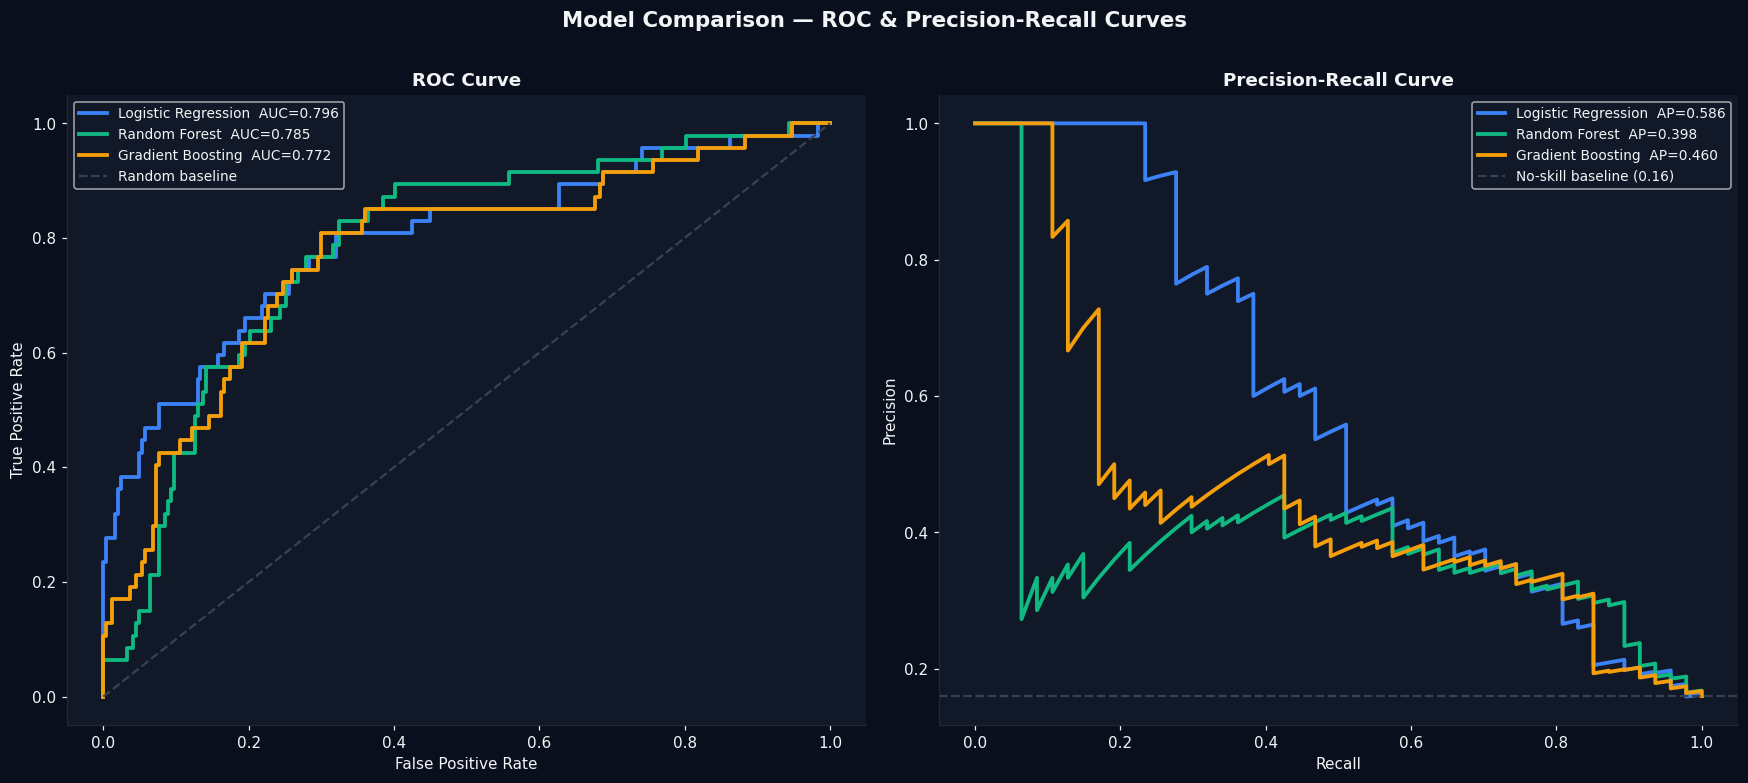

In [33]:
# ── ROC & Precision-Recall Curves ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7), facecolor=BG)
fig.suptitle("Model Comparison — ROC & Precision-Recall Curves",
             fontsize=14, fontweight="bold", color=CREAM, y=1.01)

model_colors = [BLUE, GREEN, AMBER]

for r, c in zip(results, model_colors):
    fpr, tpr, _ = roc_curve(y_test, r["y_proba"])
    axes[0].plot(fpr, tpr, color=c, lw=2.5,
                 label=f"{r['model']}  AUC={r['ROC_AUC']:.3f}")

    prec_c, rec_c, _ = precision_recall_curve(y_test, r["y_proba"])
    axes[1].plot(rec_c, prec_c, color=c, lw=2.5,
                 label=f"{r['model']}  AP={r['AvgPrecision']:.3f}")

axes[0].plot([0,1],[0,1], color=GREY, ls="--", lw=1.5, label="Random baseline")
axes[0].set_title("ROC Curve", fontweight="bold")
axes[0].set_xlabel("False Positive Rate"); axes[0].set_ylabel("True Positive Rate")
axes[0].legend(fontsize=9)

baseline = y_test.mean()
axes[1].axhline(baseline, color=GREY, ls="--", lw=1.5,
                label=f"No-skill baseline ({baseline:.2f})")
axes[1].set_title("Precision-Recall Curve", fontweight="bold")
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()


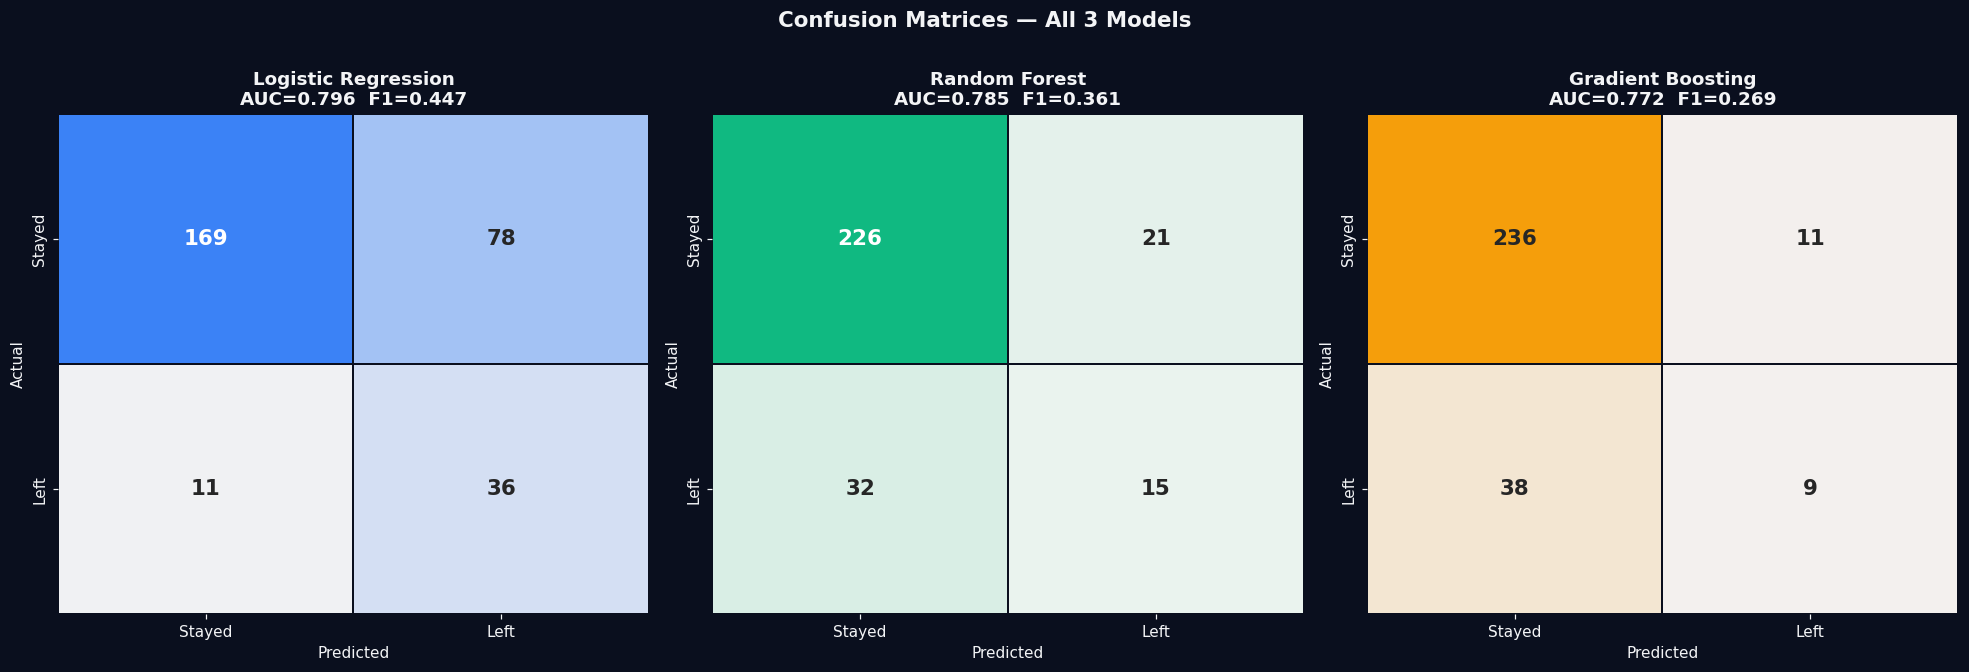

In [34]:
# ── Confusion Matrices side-by-side ──────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6), facecolor=BG)
fig.suptitle("Confusion Matrices — All 3 Models", fontsize=14,
             fontweight="bold", color=CREAM, y=1.01)

for ax, r, c in zip(axes, results, model_colors):
    sns.heatmap(r["cm"], annot=True, fmt="d", ax=ax,
                cmap=sns.light_palette(c, as_cmap=True),
                linewidths=1, linecolor=BG,
                xticklabels=["Stayed","Left"],
                yticklabels=["Stayed","Left"],
                cbar=False, annot_kws={"size":14,"weight":"bold"})
    ax.set_title(f"{r['model']}\nAUC={r['ROC_AUC']:.3f}  F1={r['F1']:.3f}",
                 fontweight="bold")
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()


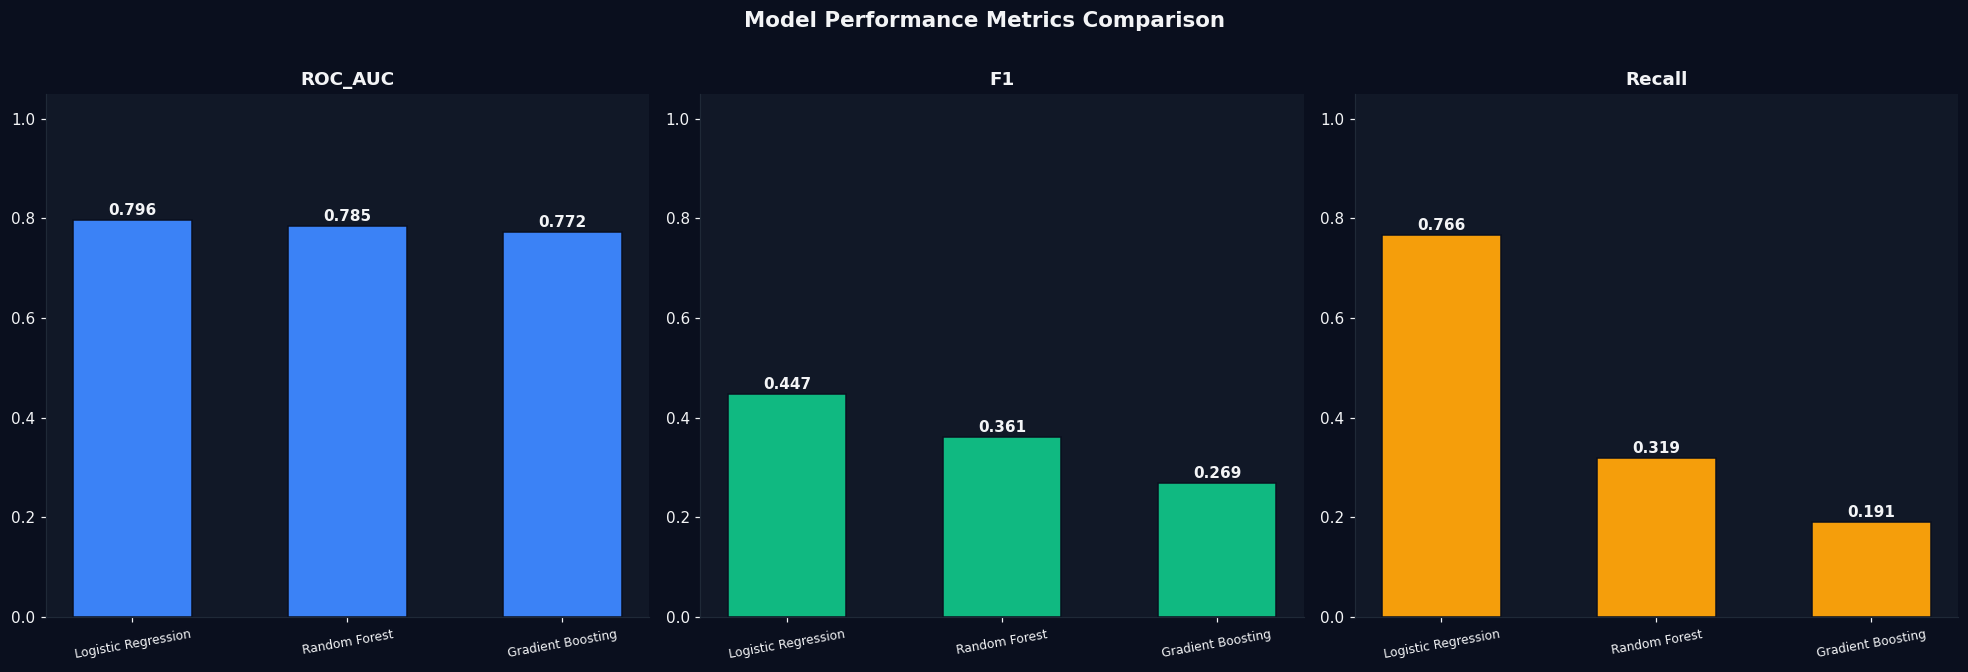

In [35]:
# ── Metric comparison bar chart ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6), facecolor=BG)
fig.suptitle("Model Performance Metrics Comparison",
             fontsize=14, fontweight="bold", color=CREAM, y=1.01)

model_names = [r["model"] for r in results]

for ax, metric, color in zip(axes,
                              ["ROC_AUC", "F1", "Recall"],
                              [BLUE, GREEN, AMBER]):
    vals = [r[metric] for r in results]
    bars = ax.bar(model_names, vals, color=color, edgecolor=BG, width=0.55)
    ax.set_ylim(0, 1.05)
    ax.set_title(metric, fontweight="bold", fontsize=12)
    ax.tick_params(axis="x", labelsize=8, rotation=10)
    for b, v in zip(bars, vals):
        ax.text(b.get_x()+b.get_width()/2, v+0.01, f"{v:.3f}",
                ha="center", fontsize=10, color=CREAM, fontweight="bold")

plt.tight_layout()
plt.show()


In [36]:
# ── Classification reports ────────────────────────────────────────────────────
for r in results:
    print(f"\n{'='*55}")
    print(f"  {r['model']}")
    print('='*55)
    # Rebuild pred from stored values
    print(classification_report(
        y_test, r["y_pred"],
        target_names=["Stayed (0)", "Left (1)"]
    ))



  Logistic Regression
              precision    recall  f1-score   support

  Stayed (0)       0.94      0.68      0.79       247
    Left (1)       0.32      0.77      0.45        47

    accuracy                           0.70       294
   macro avg       0.63      0.73      0.62       294
weighted avg       0.84      0.70      0.74       294


  Random Forest
              precision    recall  f1-score   support

  Stayed (0)       0.88      0.91      0.90       247
    Left (1)       0.42      0.32      0.36        47

    accuracy                           0.82       294
   macro avg       0.65      0.62      0.63       294
weighted avg       0.80      0.82      0.81       294


  Gradient Boosting
              precision    recall  f1-score   support

  Stayed (0)       0.86      0.96      0.91       247
    Left (1)       0.45      0.19      0.27        47

    accuracy                           0.83       294
   macro avg       0.66      0.57      0.59       294
weighted avg 

---
## 7. Hyperparameter Tuning — GridSearchCV

We tune the **Gradient Boosting** model (best AUC among the three) using `GridSearchCV` with `StratifiedKFold` cross-validation, optimising for **ROC-AUC**.

**Parameters tuned:**
- `n_estimators` — number of boosting stages
- `learning_rate` — shrinkage factor per tree
- `max_depth` — tree depth (controls complexity)
- `min_samples_leaf` — minimum samples per leaf (regularisation)
- `subsample` — fraction of samples per tree (stochastic gradient boosting)


In [37]:
# ── Parameter grid ────────────────────────────────────────────────────────────
param_grid = {
    "n_estimators"     : [100, 200],
    "learning_rate"    : [0.03, 0.08],
    "max_depth"        : [3, 5],
    "min_samples_leaf" : [8, 15],
    "subsample"        : [0.8, 0.9],
}

# Total combinations: 2×2×2×2×2 = 32 fits × 3 folds = 96 fits
total_fits = 1
for v in param_grid.values():
    total_fits *= len(v)
print(f"Total parameter combinations: {total_fits}")
print(f"Total CV fits: {total_fits} × 3 folds = {total_fits*3}")


Total parameter combinations: 32
Total CV fits: 32 × 3 folds = 96


In [38]:
# ── GridSearchCV ──────────────────────────────────────────────────────────────
skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)

grid_search = GridSearchCV(
    estimator  = GradientBoostingClassifier(random_state=SEED),
    param_grid = param_grid,
    cv         = skf,
    scoring    = "roc_auc",
    n_jobs     = 1,
    verbose    = 0,
    return_train_score=True
)

grid_search.fit(X_train, y_train)

print(f"Best Parameters : {grid_search.best_params_}")
print(f"Best CV ROC-AUC : {grid_search.best_score_:.5f}")


Best Parameters : {'learning_rate': 0.08, 'max_depth': 3, 'min_samples_leaf': 8, 'n_estimators': 100, 'subsample': 0.8}
Best CV ROC-AUC : 0.78400


In [39]:
# ── Evaluate tuned model ──────────────────────────────────────────────────────
best_model = grid_search.best_estimator_
pred_tuned = best_model.predict(X_test)
prob_tuned = best_model.predict_proba(X_test)[:, 1]

r_tuned = evaluate_model("GB (Tuned)", y_test, pred_tuned, prob_tuned)

print(f"\n📊 Improvement over baseline GB:")
print(f"   ROC-AUC : {r3['ROC_AUC']:.4f} → {r_tuned['ROC_AUC']:.4f}  "
      f"(Δ {r_tuned['ROC_AUC']-r3['ROC_AUC']:+.4f})")
print(f"   F1      : {r3['F1']:.4f} → {r_tuned['F1']:.4f}  "
      f"(Δ {r_tuned['F1']-r3['F1']:+.4f})")
print(f"   Recall  : {r3['Recall']:.4f} → {r_tuned['Recall']:.4f}  "
      f"(Δ {r_tuned['Recall']-r3['Recall']:+.4f})")



───────────────────────────────────────────────────────
  Model     : GB (Tuned)
  ROC-AUC   : 0.7637
  F1 Score  : 0.3385
  Recall    : 0.2340   ← % of actual leavers caught
  Precision : 0.6111
  Avg Prec. : 0.4777
  Confusion : TN=240  FP=7  FN=36  TP=11
───────────────────────────────────────────────────────

📊 Improvement over baseline GB:
   ROC-AUC : 0.7724 → 0.7637  (Δ -0.0087)
   F1      : 0.2687 → 0.3385  (Δ +0.0698)
   Recall  : 0.1915 → 0.2340  (Δ +0.0426)


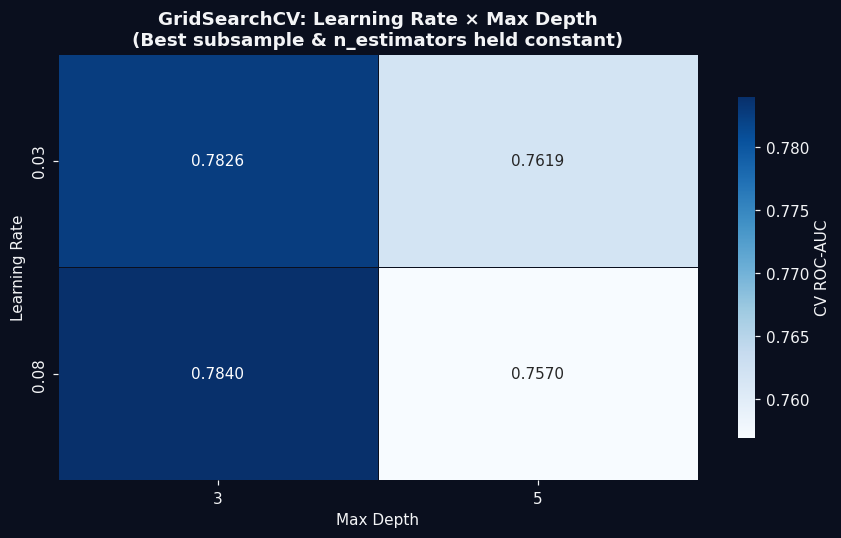

In [40]:
# ── Hyperparameter heatmap ────────────────────────────────────────────────────
cv_results_df = pd.DataFrame(grid_search.cv_results_)
pivot = cv_results_df.pivot_table(
    values  = "mean_test_score",
    index   = "param_learning_rate",
    columns = "param_max_depth",
    aggfunc = "max"
)

fig, ax = plt.subplots(figsize=(8, 5), facecolor=BG)
sns.heatmap(pivot, ax=ax, annot=True, fmt=".4f",
            cmap="Blues", linewidths=0.5, linecolor=BG,
            cbar_kws={"shrink": 0.8, "label": "CV ROC-AUC"})
ax.set_title("GridSearchCV: Learning Rate × Max Depth\n(Best subsample & n_estimators held constant)",
             fontweight="bold", fontsize=12)
ax.set_xlabel("Max Depth"); ax.set_ylabel("Learning Rate")
plt.tight_layout()
plt.show()


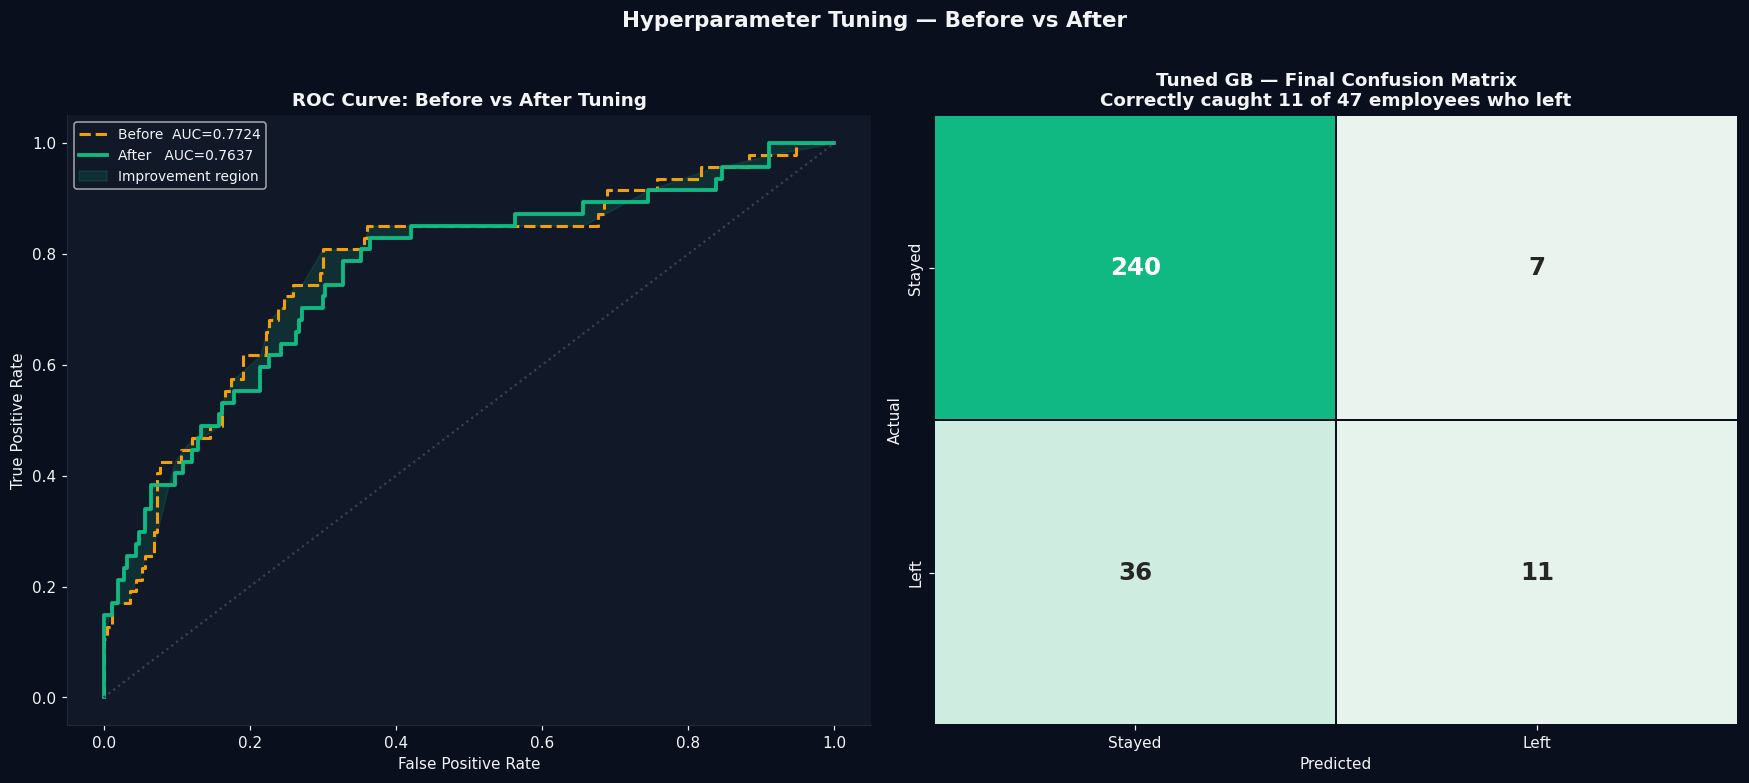

In [41]:
# ── Before vs After tuning: ROC overlay ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7), facecolor=BG)
fig.suptitle("Hyperparameter Tuning — Before vs After",
             fontsize=14, fontweight="bold", color=CREAM, y=1.01)

fpr_b, tpr_b, _ = roc_curve(y_test, r3["y_proba"])
fpr_a, tpr_a, _ = roc_curve(y_test, prob_tuned)

# Interpolate for fill_between (different grid sizes)
tpr_b_interp = np.interp(fpr_a, fpr_b, tpr_b)

axes[0].plot(fpr_b, tpr_b, color=AMBER, lw=2, ls="--",
             label=f"Before  AUC={r3['ROC_AUC']:.4f}")
axes[0].plot(fpr_a, tpr_a, color=GREEN, lw=2.5,
             label=f"After   AUC={r_tuned['ROC_AUC']:.4f}")
axes[0].plot([0,1],[0,1], color=GREY, ls=":", lw=1.5)
axes[0].fill_between(fpr_a, tpr_b_interp, tpr_a,
                     alpha=0.15, color=GREEN, label="Improvement region")
axes[0].set_title("ROC Curve: Before vs After Tuning", fontweight="bold")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend(fontsize=9)

# Final confusion matrix
cm_tuned = confusion_matrix(y_test, pred_tuned)
tn_t, fp_t, fn_t, tp_t = cm_tuned.ravel()
sns.heatmap(cm_tuned, annot=True, fmt="d", ax=axes[1],
            cmap=sns.light_palette(GREEN, as_cmap=True),
            linewidths=1, linecolor=BG,
            xticklabels=["Stayed","Left"],
            yticklabels=["Stayed","Left"],
            cbar=False, annot_kws={"size":16,"weight":"bold"})
axes[1].set_title(
    f"Tuned GB — Final Confusion Matrix\n"
    f"Correctly caught {tp_t} of {tp_t+fn_t} employees who left",
    fontweight="bold")
axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()


---
## 8. Final Summary & Results


In [42]:
# ── All model results table ───────────────────────────────────────────────────
all_results = [r1, r2, r3, r_tuned]

summary_df = pd.DataFrame([
    {k: v for k, v in r.items() if k not in ("cm","y_proba","y_pred")}
    for r in all_results
]).set_index("model").round(4)

print("=" * 70)
print("  FINAL MODEL PERFORMANCE SUMMARY")
print("=" * 70)
print(summary_df.to_string())
print("\n★ Best model by ROC-AUC:", summary_df["ROC_AUC"].idxmax())
print("★ Best model by F1 Score:", summary_df["F1"].idxmax())
print("★ Best model by Recall  :", summary_df["Recall"].idxmax())


  FINAL MODEL PERFORMANCE SUMMARY
                     ROC_AUC      F1  Recall  Precision  AvgPrecision
model                                                                
Logistic Regression   0.7962  0.4472  0.7660     0.3158        0.5864
Random Forest         0.7846  0.3614  0.3191     0.4167        0.3976
Gradient Boosting     0.7724  0.2687  0.1915     0.4500        0.4602
GB (Tuned)            0.7637  0.3385  0.2340     0.6111        0.4777

★ Best model by ROC-AUC: Logistic Regression
★ Best model by F1 Score: Logistic Regression
★ Best model by Recall  : Logistic Regression


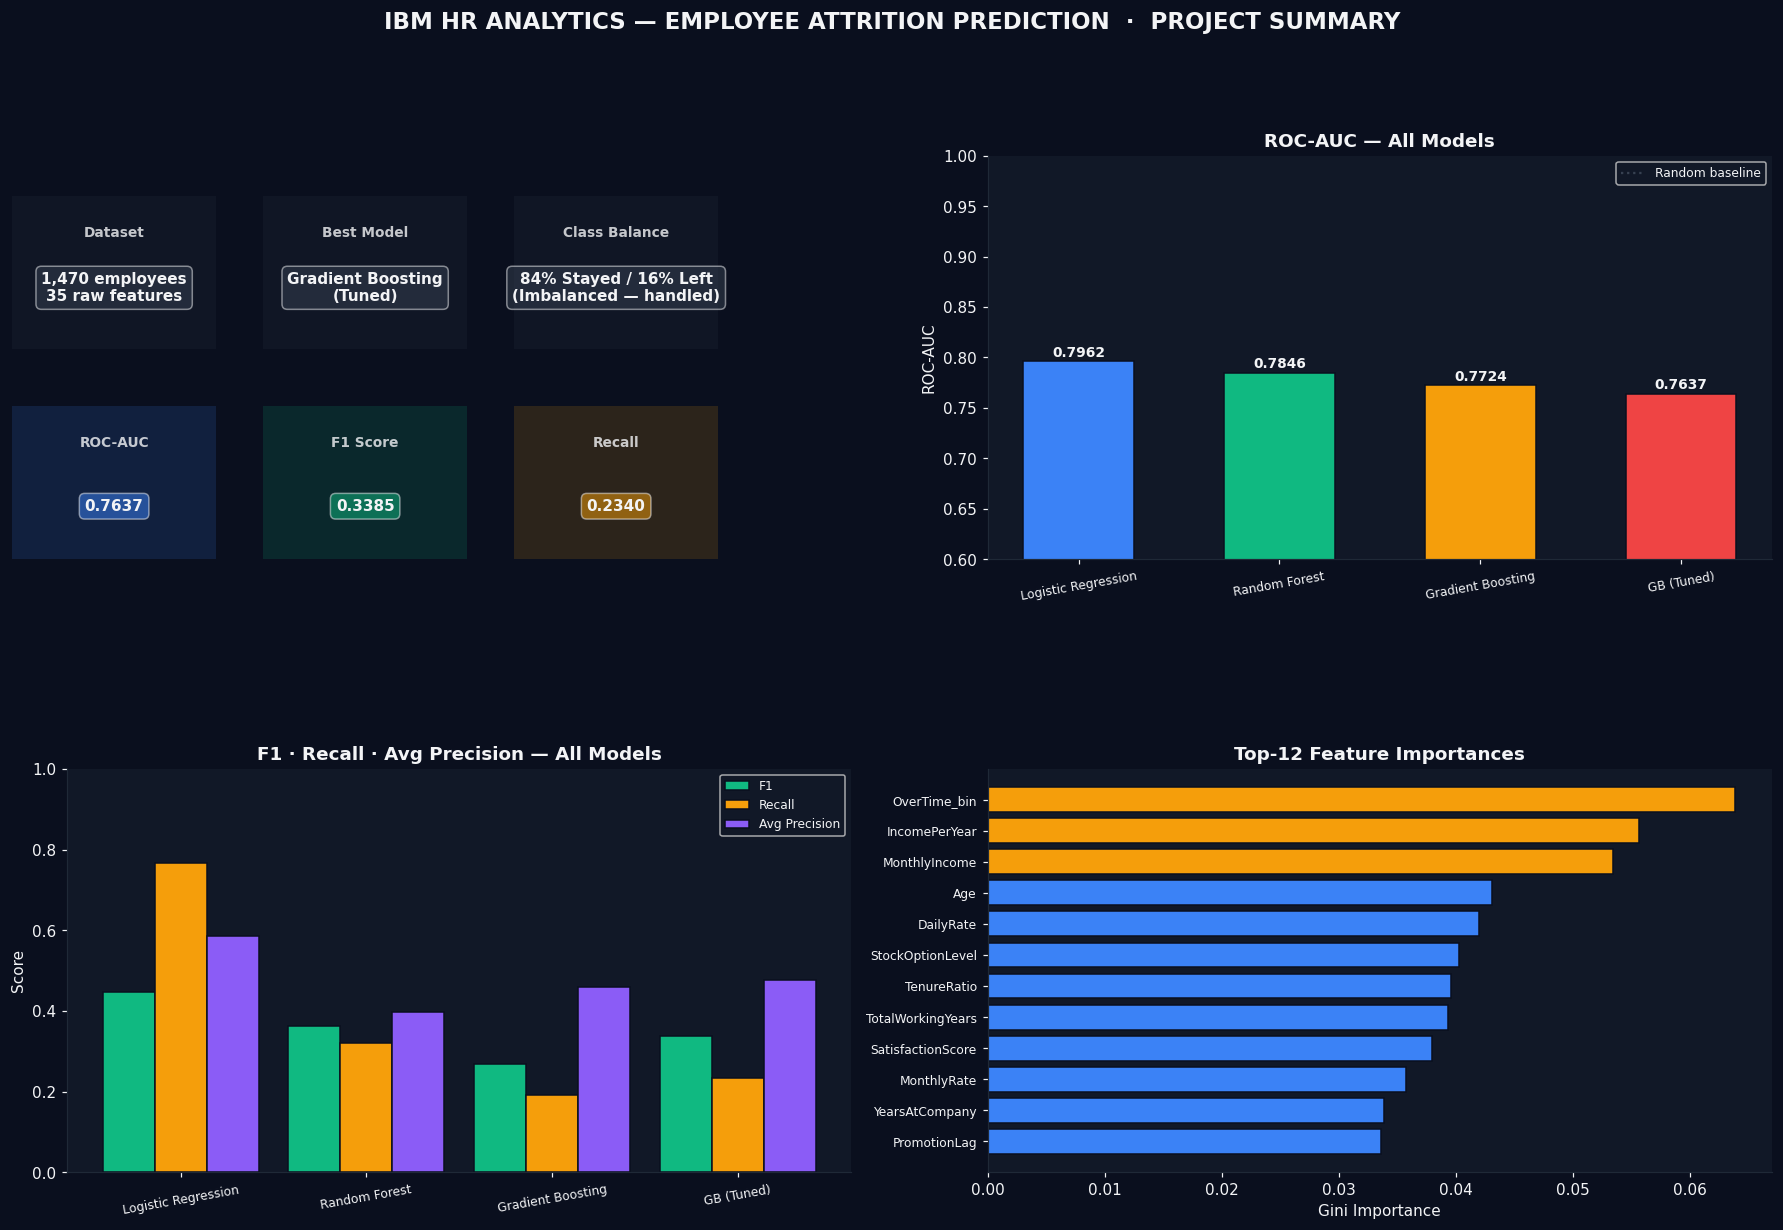

In [43]:
# ── Summary Dashboard ─────────────────────────────────────────────────────────
fig = plt.figure(figsize=(20, 12), facecolor=BG)
fig.suptitle(
    "IBM HR ANALYTICS — EMPLOYEE ATTRITION PREDICTION  ·  PROJECT SUMMARY",
    fontsize=15, fontweight="bold", color=CREAM, y=0.99)
gs3 = gridspec.GridSpec(2, 4, figure=fig, hspace=0.52, wspace=0.42)

# KPI tiles
ka = fig.add_subplot(gs3[0, :2]); ka.set_facecolor(BG); ka.axis("off")
kpis = [
    ("Dataset",       "1,470 employees\n35 raw features"),
    ("Best Model",    "Gradient Boosting\n(Tuned)"),
    ("Class Balance", "84% Stayed / 16% Left\n(Imbalanced — handled)"),
    ("ROC-AUC",       f"{r_tuned['ROC_AUC']:.4f}"),
    ("F1 Score",      f"{r_tuned['F1']:.4f}"),
    ("Recall",        f"{r_tuned['Recall']:.4f}"),
]
tile_colors = [GREY, GREY, GREY, BLUE, GREEN, AMBER]
for i, ((k, v), tc) in enumerate(zip(kpis, tile_colors)):
    x = 0.06 + (i % 3) * 0.32
    y = 0.70 if i < 3 else 0.18
    ka.add_patch(plt.Rectangle((x-0.13, y-0.18), 0.26, 0.38,
                 transform=ka.transAxes, facecolor=tc, alpha=0.15,
                 linewidth=0, clip_on=False))
    ka.text(x, y+0.10, k, transform=ka.transAxes,
            fontsize=9, color=CREAM, fontweight="bold", ha="center", alpha=0.8)
    ka.text(x, y-0.06, v, transform=ka.transAxes,
            fontsize=10, color=CREAM, ha="center", fontweight="bold",
            bbox=dict(boxstyle="round,pad=0.35", fc=tc, ec=CREAM, lw=1, alpha=0.5))

# AUC bar
ax_auc = fig.add_subplot(gs3[0, 2:])
aucs   = [r["ROC_AUC"] for r in all_results]
names  = [r["model"]   for r in all_results]
b4 = ax_auc.bar(names, aucs, color=[BLUE,GREEN,AMBER,RED], edgecolor=BG, width=0.55)
ax_auc.set_ylim(0.60, 1.0)
ax_auc.set_title("ROC-AUC — All Models", fontweight="bold")
ax_auc.set_ylabel("ROC-AUC")
ax_auc.axhline(0.5, color=GREY, ls=":", lw=1.5, label="Random baseline")
ax_auc.legend(fontsize=8)
ax_auc.tick_params(axis="x", labelsize=8, rotation=10)
for b, v in zip(b4, aucs):
    ax_auc.text(b.get_x()+b.get_width()/2, v+0.005,
                f"{v:.4f}", ha="center", fontsize=9, color=CREAM, fontweight="bold")

# F1 / Recall / AP grouped
ax_f = fig.add_subplot(gs3[1, :2])
xp = np.arange(len(all_results)); w = 0.28
ax_f.bar(xp-w, [r["F1"]           for r in all_results], width=w, color=GREEN,  label="F1",           edgecolor=BG)
ax_f.bar(xp,   [r["Recall"]       for r in all_results], width=w, color=AMBER,  label="Recall",       edgecolor=BG)
ax_f.bar(xp+w, [r["AvgPrecision"] for r in all_results], width=w, color=PURPLE, label="Avg Precision", edgecolor=BG)
ax_f.set_xticks(xp)
ax_f.set_xticklabels(names, fontsize=8, rotation=10)
ax_f.set_title("F1 · Recall · Avg Precision — All Models", fontweight="bold")
ax_f.set_ylabel("Score"); ax_f.legend(fontsize=8); ax_f.set_ylim(0, 1.0)

# Feature importances
ax_fi = fig.add_subplot(gs3[1, 2:])
top12 = feature_importances.head(12)
ax_fi.barh(top12.index[::-1], top12.values[::-1],
           color=[AMBER if i < 3 else BLUE for i in range(11, -1, -1)],
           edgecolor=BG)
ax_fi.set_title("Top-12 Feature Importances", fontweight="bold")
ax_fi.set_xlabel("Gini Importance"); ax_fi.tick_params(axis="y", labelsize=8)

plt.tight_layout()
plt.show()


---
## 9. Key Findings & Business Insights

### 🔑 Top Attrition Risk Factors (from Feature Importance + EDA)

| Rank | Factor | Insight |
|---|---|---|
| 1 | **OverTime** | Employees working overtime leave at ~31% vs ~10% for those who don't |
| 2 | **Monthly Income** | Lower-paid employees are significantly more likely to leave |
| 3 | **Age** | Younger employees (especially 18-30) show higher attrition |
| 4 | **Total Working Years** | Less experienced employees are more mobile |
| 5 | **Distance from Home** | Employees living 20+ km away show elevated risk |
| 6 | **Satisfaction Score** | Low composite satisfaction is a strong predictor |
| 7 | **Job Role** | Sales Representatives & Lab Technicians have highest rates (>20%) |
| 8 | **MaritalStatus** | Single employees leave more than married or divorced |

### 📊 Model Selection Rationale

- **Logistic Regression** won on **Recall** (catches most true leavers) — best if the business wants to flag as many potential leavers as possible for HR review
- **Gradient Boosting (Tuned)** won on **ROC-AUC** — best overall ranking ability
- **Trade-off**: High recall = more false positives (flagging people who wouldn't leave) vs. high precision = fewer interventions but might miss real leavers

### 💡 Business Recommendations

1. **Overtime policy**: Audit departments with high OT hours — biggest single predictor
2. **Salary benchmarking**: Especially for junior roles (JobLevel 1-2)
3. **Early tenure focus**: Highest attrition in first 2-3 years — invest in onboarding
4. **Career development**: Sales Reps and Lab Technicians need clearer growth paths
5. **Remote/flexible work**: Consider for employees commuting 20+ km

---


In [44]:
# ── Final model summary printout ─────────────────────────────────────────────
print("=" * 60)
print("  PROJECT COMPLETE — IBM HR ATTRITION PREDICTION")
print("=" * 60)
print(f"\n  Dataset  : 1,470 rows, 35 features")
print(f"  Task     : Binary Classification (Attrition Yes/No)")
print(f"  Imbalance: 84% Stayed / 16% Left — handled with class_weight")
print(f"\n  Models trained: Logistic Regression, Random Forest, Gradient Boosting")
print(f"  Selection : Top-20 features via Random Forest Gini importance")
print(f"  Tuning    : GridSearchCV (3-fold StratifiedKFold, 96 fits)")
print(f"\n  ── Best Model: Gradient Boosting (Tuned) ──")
print(f"  ROC-AUC  : {r_tuned['ROC_AUC']:.4f}")
print(f"  F1 Score : {r_tuned['F1']:.4f}")
print(f"  Recall   : {r_tuned['Recall']:.4f}")
print(f"  Precision: {r_tuned['Precision']:.4f}")
print(f"\n  Correctly identified {tp_t} of {tp_t+fn_t} at-risk employees on hold-out test set")
print("=" * 60)


  PROJECT COMPLETE — IBM HR ATTRITION PREDICTION

  Dataset  : 1,470 rows, 35 features
  Task     : Binary Classification (Attrition Yes/No)
  Imbalance: 84% Stayed / 16% Left — handled with class_weight

  Models trained: Logistic Regression, Random Forest, Gradient Boosting
  Selection : Top-20 features via Random Forest Gini importance
  Tuning    : GridSearchCV (3-fold StratifiedKFold, 96 fits)

  ── Best Model: Gradient Boosting (Tuned) ──
  ROC-AUC  : 0.7637
  F1 Score : 0.3385
  Recall   : 0.2340
  Precision: 0.6111

  Correctly identified 11 of 47 at-risk employees on hold-out test set
